# Problem Statement

### **Problem Statement**  

Ebola, like many infectious diseases, poses a **significant public health risk**. **Early prediction** of expected cases and deaths in various regions is **crucial** for **effective resource allocation, timely intervention, and containment efforts**.  

In this challenge, we aim to **develop a machine learning model** that can **predict**:  
✅ The **number of deaths**  
✅ The **number of confirmed cases**  
✅ The **Case Fatality Ratio (CFR)**  

The dataset includes:  
- **Geographical information** (latitude & longitude)  
- **Reported deaths in some regions** (while missing in others)  
- **Existing CFR data** for specific locations  

Using this data, we must **forecast** deaths, confirmed cases, and CFR for **unreported regions**.  

---

### **What We Need to Do**  
🔹 **Analyze** spatial and epidemiological data  
🔹 **Build a machine learning model** to predict Ebola cases & fatalities  
🔹 **Identify patterns** in disease spread  
🔹 **Provide actionable insights** for early intervention & resource allocation  

This project will help in **early outbreak detection, targeted resource distribution, and better public health response strategies**. 🚀  


# Our Research

### **Transmission**  

EVD, like other viral diseases, can be transmitted through:  
- **Person-to-person**
Ebola can spread through direct contact with the blood, saliva, urine, feces, vomit, breast milk, or amniotic fluid of an infected person. This can include contact with a sick person's clothing, bedding, needles, or medical equipment.
- **Animal-to-person**
Ebola can spread through contact with an infected animal, such as a bat or primate.   

- **Contact with a sick or deceased person** infected with EVD.  





### **Case Fatality Rate (CFR)**  

The **Case Fatality Rate (CFR)** represents the proportion of people who die from a specific disease among all individuals diagnosed with it.  



### **Spatial Analysis in Disease Transmission**  

#### **Spatial Lag**  
- **Spatial lag** captures the **average value of a target variable** (e.g., deaths) for neighboring points within a defined geographic radius.  
- This feature helps the model account for **spatial dependencies** by reflecting the influence of a location's surroundings.  



#### **Clustering vs. Spatial Lag**  
- **Clustering** groups locations into distinct regions and aggregates values within those clusters (e.g., cluster mean deaths).  
- **Spatial Lag** focuses on **individual locations** and aggregates values from specific neighboring areas within a given radius.  


### **Hot Spot**  
- The **spread of EVD is higher in temperate zones** compared to tropical zones.  
- **Drier regions** experience **lower transmission rates**.  
- You can analyze this **multiple times** to gain deeper insights.  



### **Insights from the Analysis**  
- **Temperature plays a crucial role** in virus survival and transmission.  
- The virus **thrives in cooler environments** but struggles in **warmer climates**.  
- The **highest transmission rates** occur in **temperate zones** where the **average temperature ranges between 5–10°C**.  
- The **tropical zone** (average temperature **>25°C**) shows **minimal transmission**.  



### **Supporting Research**  
An **evidential excerpt** from a referenced research paper further supports these findings:  

> In the early 1960s, **Schulman and Kilbourne** developed an **influenza virus transmission model** in mice.  
> Although **mouse-to-mouse transmission** is relatively inefficient, they observed a **significant decrease in transmission efficiency with increasing relative humidity (RH)** [23].  

##### **Key Findings from Lowen et al.'s Guinea Pig Transmission Model**  
- At **20°C**, transmission efficiency of **influenza A/H3N2** showed a **bimodal dependence on RH**:  
  - **Maximal at 20–35% RH**  
  - **Poor at 50% RH**  
  - **Moderate at 65% RH**  
  - **Absent at 80% RH**  
- At **5°C**, transmission was generally **more efficient than at 20°C**, with a **monotonic decrease** in efficiency as RH increased [25].  
- **Transmission was completely abolished at high temperatures (30°C)**, regardless of RH [26].  

---

### **Key Takeaways**  
✅ **Cooler temperatures (5–10°C) facilitate viral transmission**.  
✅ **Higher temperatures (≥30°C) significantly reduce transmission**.  
✅ **Humidity plays a role, but temperature remains a dominant factor**.  


# Install Required Library

In [48]:
!pip install pycountry reverse_geocoder pykrige

# Imports

In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score
from scipy.spatial.distance import cdist
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
import folium
from geopy.geocoders import Nominatim
import pycountry
import reverse_geocoder as rg
from sklearn.cluster import DBSCAN
from math import radians
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree
from math import radians

# Load Data

In [51]:
print("Loading data...")
train_df = pd.read_csv('train_df.csv')
test_df = pd.read_csv('test_df.csv')

Loading data...


# Analysis of Given Data

In [52]:
train_df.info(),test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4016 entries, 0 to 4015
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Lat                  3925 non-null   float64
 1   Long_                3925 non-null   float64
 2   Deaths               2458 non-null   float64
 3   Case_Fatality_Ratio  3972 non-null   float64
dtypes: float64(4)
memory usage: 125.6 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004 entries, 0 to 1003
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Lat     981 non-null    float64
 1   Long_   981 non-null    float64
dtypes: float64(2)
memory usage: 15.8 KB


(None, None)

**So there are null values in both train and test data**
  

In [53]:
train_df.describe()

,Lat,Long_,Deaths,Case_Fatality_Ratio
count,3925.000000,3925.000000,2458.000000,3972.000000
mean,35.736183,-71.109728,70.753051,3.904119
std,13.441327,55.361480,55.362369,123.020033
min,-71.949900,-178.116500,0.000000,0.000000
25%,33.191535,-96.595639,23.000000,0.890466
50%,37.895700,-86.717326,60.000000,1.285465
75%,42.176955,-77.357900,111.000000,1.737771
max,71.706900,178.065000,200.000000,7570.769231


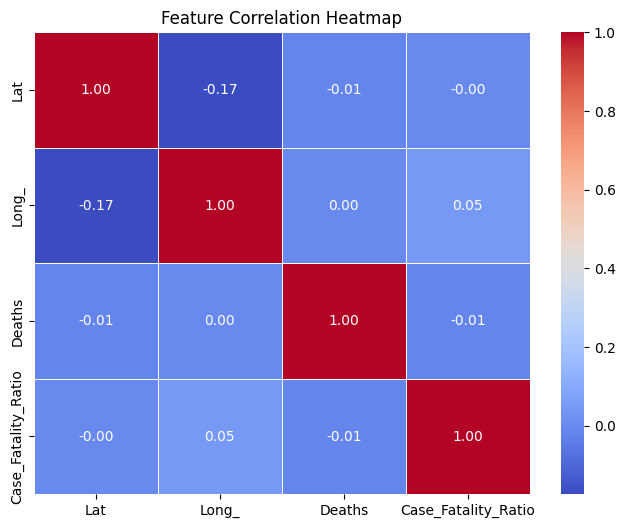

In [54]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Compute correlation matrix
corr_matrix = train_df.corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)

# Show the heatmap
plt.title("Feature Correlation Heatmap")
plt.show()


So on this basis we see there is no linear relationship between Lat,Long with Target columns Death and Case_Fatality_Ratio

In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis


Target_column = 'Deaths'

# 1. Descriptive Statistics
print("Descriptive Statistics:")
print(train_df[Target_column].describe())

from scipy.stats import skew, kurtosis

# Filter out NaN values from the 'deaths' column
non_nan_deaths = train_df[Target_column].dropna()

# 2. Skewness
skewness_value = skew(non_nan_deaths)
print(f"\nSkewness: {skewness_value:.3f}")

# 3. Kurtosis
kurtosis_value = kurtosis(non_nan_deaths)
print(f"\nKurtosis: {kurtosis_value:.3f}")

Descriptive Statistics:
count    2458.000000
mean       70.753051
std        55.362369
min         0.000000
25%        23.000000
50%        60.000000
75%       111.000000
max       200.000000
Name: Deaths, dtype: float64

Skewness: 0.558

Kurtosis: -0.776


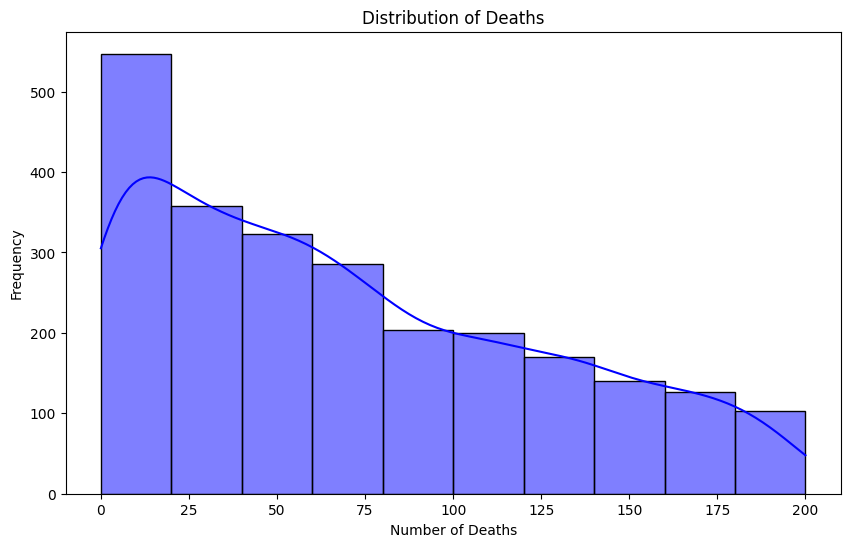

In [56]:
# 4. Distribution Plot
plt.figure(figsize=(10, 6))
sns.histplot(train_df[Target_column], kde=True, bins=10, color='blue')
plt.title("Distribution of Deaths")
plt.xlabel("Number of Deaths")
plt.ylabel("Frequency")
plt.show()

Distribution seem to be Log-normal which seem to be in the viral outbreaks like COVID 19 and Ebola.

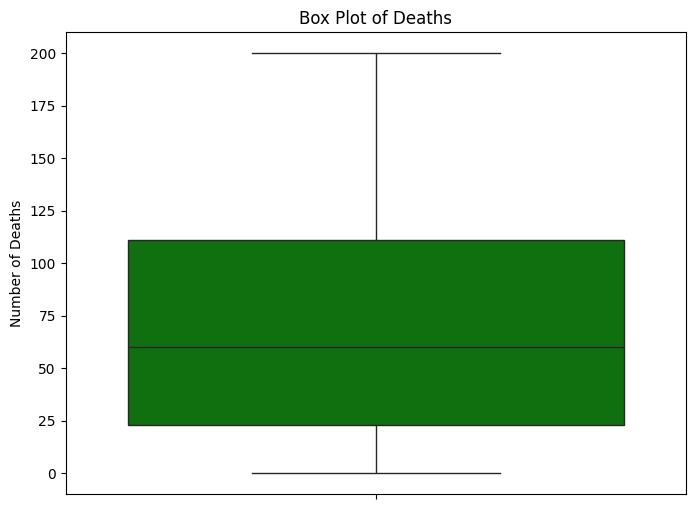

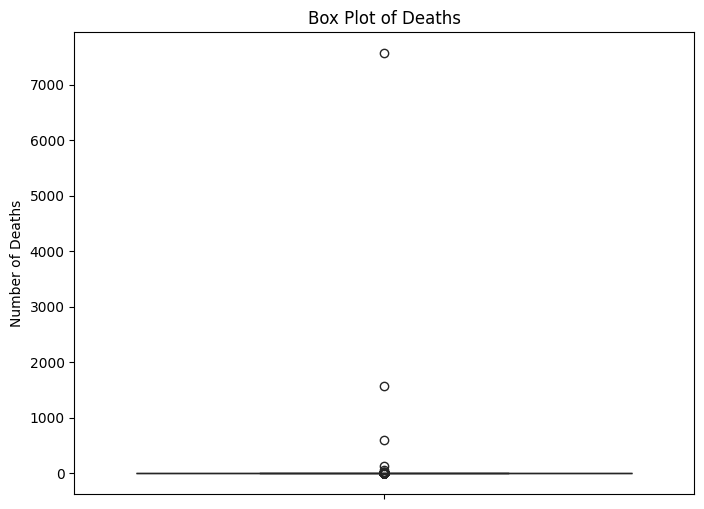

In [57]:
# 5. Box Plot
plt.figure(figsize=(8, 6))
sns.boxplot(y=train_df[Target_column], color='green')
plt.title("Box Plot of Deaths")
plt.ylabel("Number of Deaths")
plt.show()

# 5. Box Plot
plt.figure(figsize=(8, 6))
sns.boxplot(y=train_df['Case_Fatality_Ratio'], color='green')
plt.title("Box Plot of Deaths")
plt.ylabel("Number of Deaths")
plt.show()


SO no outlier is there in the Deaths columns and while there are some in CFR.

In [58]:
# 6. Outlier Detection
q1 = train_df[Target_column].quantile(0.25)
q3 = train_df[Target_column].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = train_df[(train_df[Target_column] < lower_bound) | (train_df[Target_column] > upper_bound)]
print(f"\nOutliers in 'deaths':\n{outliers.shape}")

# 7. Zero Deaths Percentage
zero_deaths_percentage = (train_df[Target_column] == 0).mean() * 100
print(f"\nPercentage of entries with zero deaths: {zero_deaths_percentage:.2f}%")

# 8. Checking if there are any remaining NaN values
missing_values = train_df[Target_column].isna().sum()
print(f"Number of missing values in 'Deaths' after imputation: {missing_values}")


Outliers in 'deaths':
(0, 4)

Percentage of entries with zero deaths: 4.18%
Number of missing values in 'Deaths' after imputation: 1558


In [59]:
Target_column = 'Case_Fatality_Ratio'
# 6. Outlier Detection
q1 = train_df[Target_column].quantile(0.25)
q3 = train_df[Target_column].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = train_df[(train_df[Target_column] < lower_bound) | (train_df[Target_column] > upper_bound)]
print(f"\nOutliers in 'deaths':\n{outliers.shape}")

# 7. Zero Deaths Percentage
zero_deaths_percentage = (train_df[Target_column] == 0).mean() * 100
print(f"\nPercentage of entries with zero deaths: {zero_deaths_percentage:.2f}%")

# 8. Checking if there are any remaining NaN values
missing_values = train_df[Target_column].isna().sum()
print(f"Number of missing values in 'Deaths' after imputation: {missing_values}")


Outliers in 'deaths':
(150, 4)

Percentage of entries with zero deaths: 3.31%
Number of missing values in 'Deaths' after imputation: 44


# Cleaning Train and Test Data


First we will drop the rows where
  1. Latitude and Longitude is Null
  2. CFR is Greater than 100 , which is not possible

In [60]:
def clean_data(df):
    """Clean the dataframe and handle missing values."""
    df = df.copy()
    df = df.dropna(subset=['Lat', 'Long_'])
    df = df.replace([np.inf, -np.inf], np.nan)
    if 'Deaths' in df.columns:
        df.loc[df['Deaths'] < 0, 'Deaths'] = np.nan
    if 'Case_Fatality_Ratio' in df.columns:
        df.loc[df['Case_Fatality_Ratio'] < 0, 'Case_Fatality_Ratio'] = np.nan
        df = df.dropna(subset=['Lat', 'Long_','Case_Fatality_Ratio'])
        df = df[df['Case_Fatality_Ratio'] <= 100]
    return df

In [61]:
# Clean data
train_df = clean_data(train_df)
test_df = clean_data(test_df)
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

#EDA (Exploratory Data Analysis)

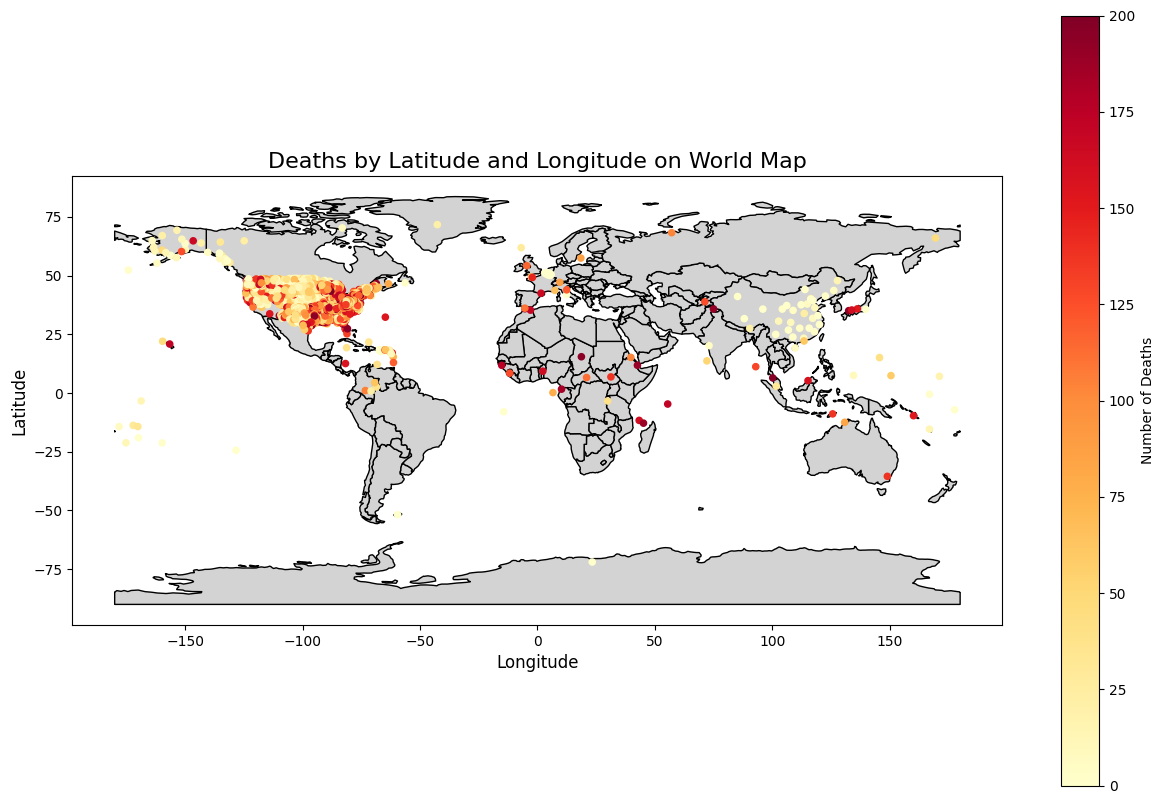

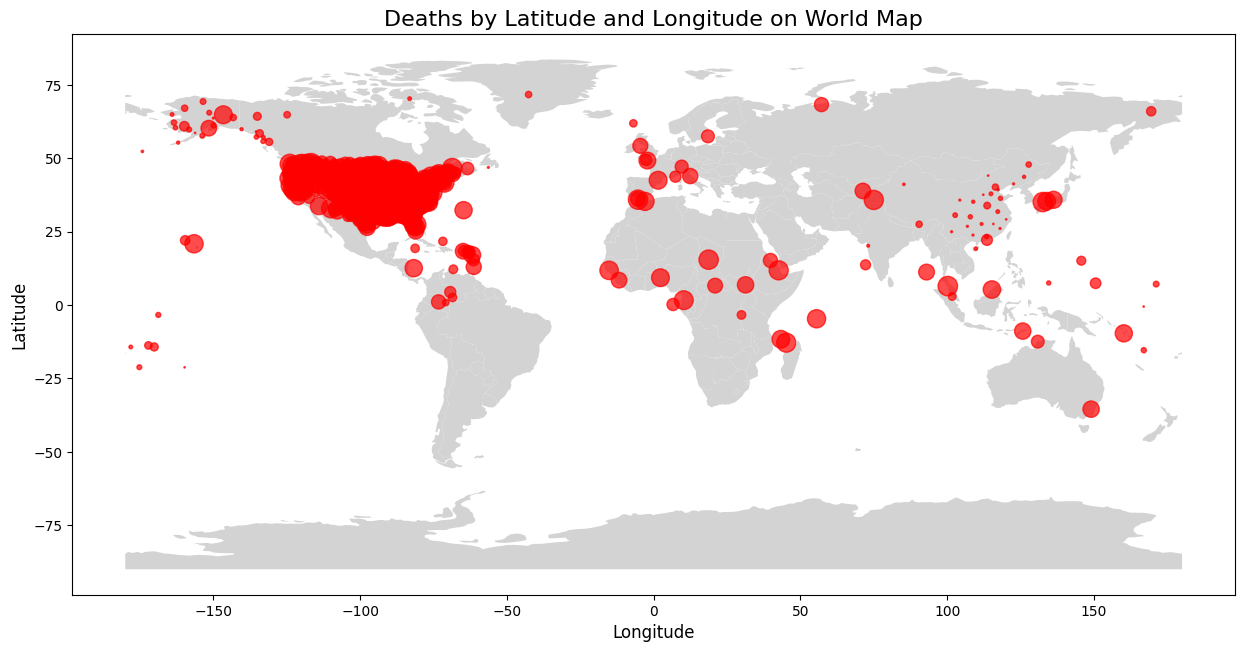

In [62]:
import geopandas as gpd
import matplotlib.pyplot as plt

def plot_deaths_on_map(df, latitude_col='Lat', longitude_col='Long_', deaths_col='Deaths'):
    """
    Plots the number of deaths on a world map based on latitude and longitude.

    Parameters:
        df (DataFrame): Input DataFrame with latitude, longitude, and deaths columns.
        latitude_col (str): Name of the column containing latitude values. Default is 'latitude'.
        longitude_col (str): Name of the column containing longitude values. Default is 'longitude'.
        deaths_col (str): Name of the column containing death count. Default is 'deaths'.
    """
    # Load the world map shapefile
    url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(url)

    # Create a GeoDataFrame for the points
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[longitude_col], df[latitude_col])
    )

    # Plot the world map
    fig, ax = plt.subplots(figsize=(15, 10))
    world.plot(ax=ax, color='lightgray', edgecolor='black')

    # Plot the points on the map with a color gradient
    scatter = gdf.plot(
        ax=ax,
        column=deaths_col,  # Use deaths_col to determine the color
        cmap='YlOrRd',      # Color gradient from light yellow to dark red
        markersize=20,      # Fixed marker size
        legend=True,        # Add a legend
        legend_kwds={'label': "Number of Deaths"}
    )

    # Add titles and labels
    plt.title('Deaths by Latitude and Longitude on World Map', fontsize=16)
    plt.xlabel('Longitude', fontsize=12)
    plt.ylabel('Latitude', fontsize=12)

    # Show plot
    plt.show()

def plot_world_map_with_deaths(df, latitude_col='Lat', longitude_col='Long_', deaths_col='Deaths'):
    """
    Plots the number of deaths on a world map with marker size scaled by the number of deaths.

    Parameters:
        df (DataFrame): Input DataFrame with latitude, longitude, and deaths columns.
        latitude_col (str): Name of the column containing latitude values. Default is 'latitude'.
        longitude_col (str): Name of the column containing longitude values. Default is 'longitude'.
        deaths_col (str): Name of the column containing death count. Default is 'deaths'.
    """
    import geopandas as gpd
    import matplotlib.pyplot as plt

    # Load the world map shapefile
    url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(url)

    # Create a GeoDataFrame for the points
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[longitude_col], df[latitude_col])
    )

    # Plot the world map
    fig, ax = plt.subplots(figsize=(15, 10))
    world.plot(ax=ax, color='lightgray')

    # Plot the points on the map with size scaled by the deaths column
    gdf.plot(
        ax=ax,
        color='red',
        markersize=gdf[deaths_col],  # Scale size by deaths
        alpha=0.7
    )

    # Add titles and labels
    plt.title('Deaths by Latitude and Longitude on World Map', fontsize=16)
    plt.xlabel('Longitude', fontsize=12)
    plt.ylabel('Latitude', fontsize=12)

    # Show plot
    plt.show()

# Example usage:
plot_deaths_on_map(train_df)
plot_world_map_with_deaths(train_df)


**For null values**

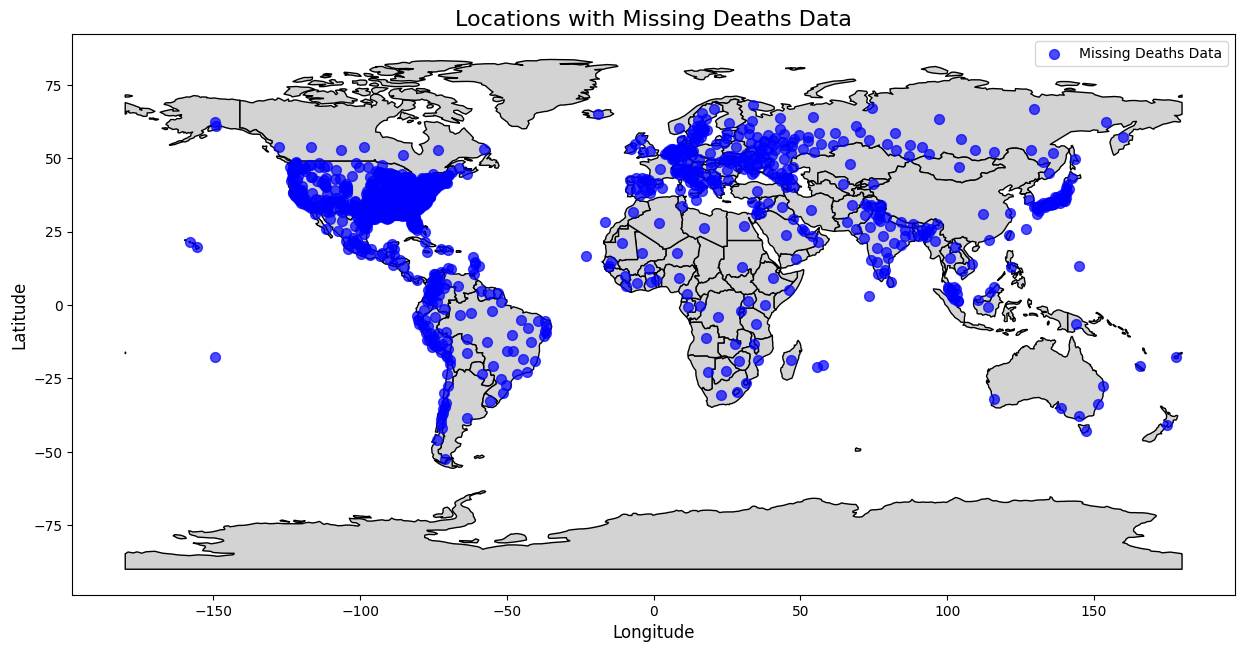

In [63]:
import geopandas as gpd
import matplotlib.pyplot as plt

def plot_deaths_on_map(df, latitude_col='Lat', longitude_col='Long_', deaths_col='Deaths'):
    """
    Plots locations with missing deaths data on a world map.
    """
    # Load the world map
    url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(url)

    # Create a GeoDataFrame for the points with missing deaths
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[longitude_col], df[latitude_col])
    )

    # Plot the world map
    fig, ax = plt.subplots(figsize=(15, 10))
    world.plot(ax=ax, color='lightgray', edgecolor='black')

    # Plot locations with missing deaths data
    gdf.plot(
        ax=ax,
        color='blue',  # Different color for missing deaths
        markersize=50,  # Size of markers
        alpha=0.7,
        label="Missing Deaths Data"
    )

    # Add titles and legend
    plt.title('Locations with Missing Deaths Data', fontsize=16)
    plt.xlabel('Longitude', fontsize=12)
    plt.ylabel('Latitude', fontsize=12)
    plt.legend()

    # Show plot
    plt.show()

def plot_world_map_with_deaths(df, latitude_col='Lat', longitude_col='Long_', deaths_col='Deaths'):
    """
    Plots locations with missing deaths data on a world map using markers.
    """
    # Load the world map
    url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(url)

    # Create a GeoDataFrame for the points
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[longitude_col], df[latitude_col])
    )

    # Plot the world map
    fig, ax = plt.subplots(figsize=(15, 10))
    world.plot(ax=ax, color='lightgray', edgecolor='black')

    # Plot points with missing deaths (highlight in blue)
    gdf.plot(
        ax=ax,
        color='blue',
        markersize=50,  # Fixed size since deaths are missing
        alpha=0.7,
        label="Missing Deaths Data"
    )

    # Add titles and labels
    plt.title('Locations with Missing Deaths Data', fontsize=16)
    plt.xlabel('Longitude', fontsize=12)
    plt.ylabel('Latitude', fontsize=12)
    plt.legend()

    # Show plot
    plt.show()

# Example usage:
missing_deaths_df = train_df[train_df['Deaths'].isna()].copy()

plot_deaths_on_map(missing_deaths_df)
# plot_world_map_with_deaths(missing_deaths_df)


In [64]:
def add_country_features(df):
    """Add country-based features."""
    df = df.dropna(subset=['Lat','Long_'])
    coordinates = list(zip(df['Lat'], df['Long_']))
    results = rg.search(coordinates, mode=1)
    df['country_code'] = [result['cc'] for result in results]

    def alpha2_to_alpha3(alpha2_code):
        try:
            return pycountry.countries.get(alpha_2=alpha2_code).alpha_3
        except AttributeError:
            return None

    df['country_code'] = df['country_code'].apply(alpha2_to_alpha3)
    return df

train_df = add_country_features(train_df)
train_df['country_code'].fillna('GLOBAL', inplace=True)

test_df = add_country_features(test_df)
test_df['country_code'].fillna('GLOBAL', inplace=True)

<ipython-input-64-b225096a05a3>:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['country_code'].fillna('GLOBAL', inplace=True)
<ipython-input-64-b225096a05a3>:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

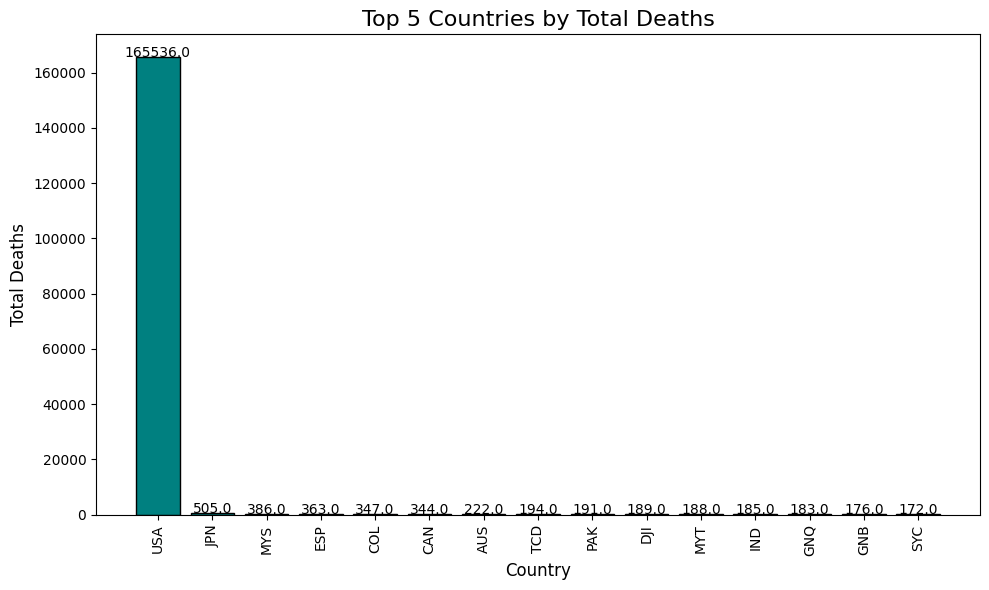

In [65]:
import matplotlib.pyplot as plt

Target_column = 'Deaths'
# Group by country and sum the deaths for each country
df_grouped = train_df.groupby('country_code')[Target_column].sum().reset_index()

# Sort by deaths in descending order and select the top 5
df_top5 = df_grouped.sort_values(by=Target_column, ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(df_top5['country_code'], df_top5[Target_column], color='teal', edgecolor='black')

# Add titles and labels
plt.title('Top 5 Countries by Total Deaths', fontsize=16)
plt.xlabel('Country', fontsize=12)
# Set x-axis tick labels and rotate them vertically
plt.xticks(df_top5['country_code'], rotation='vertical')
plt.ylabel('Total Deaths', fontsize=12)

# Annotate values on the bars
for index, value in enumerate(df_top5[Target_column]):
    plt.text(index, value + 5, str(value), ha='center', fontsize=10)

# Show plot
plt.tight_layout()
plt.show()


So the most death is in USA so this dataset is very baised towards to USA

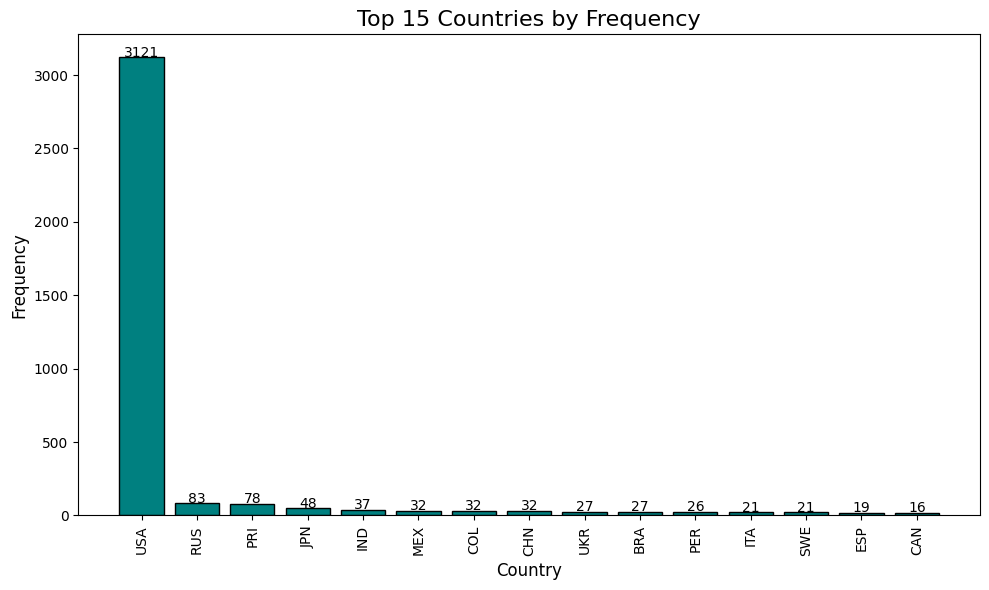

In [66]:
import matplotlib.pyplot as plt

# Count occurrences of each country_code
df_grouped = train_df['country_code'].value_counts().reset_index()
df_grouped.columns = ['country_code', 'count']

# Select the top 15 most frequent countries
df_top15 = df_grouped.head(15)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(df_top15['country_code'], df_top15['count'], color='teal', edgecolor='black')

# Add titles and labels
plt.title('Top 15 Countries by Frequency', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.xticks(rotation='vertical')
plt.ylabel('Frequency', fontsize=12)

# Annotate values on the bars
for index, value in enumerate(df_top15['count']):
    plt.text(index, value + 5, str(value), ha='center', fontsize=10)

# Show plot
plt.tight_layout()
plt.show()


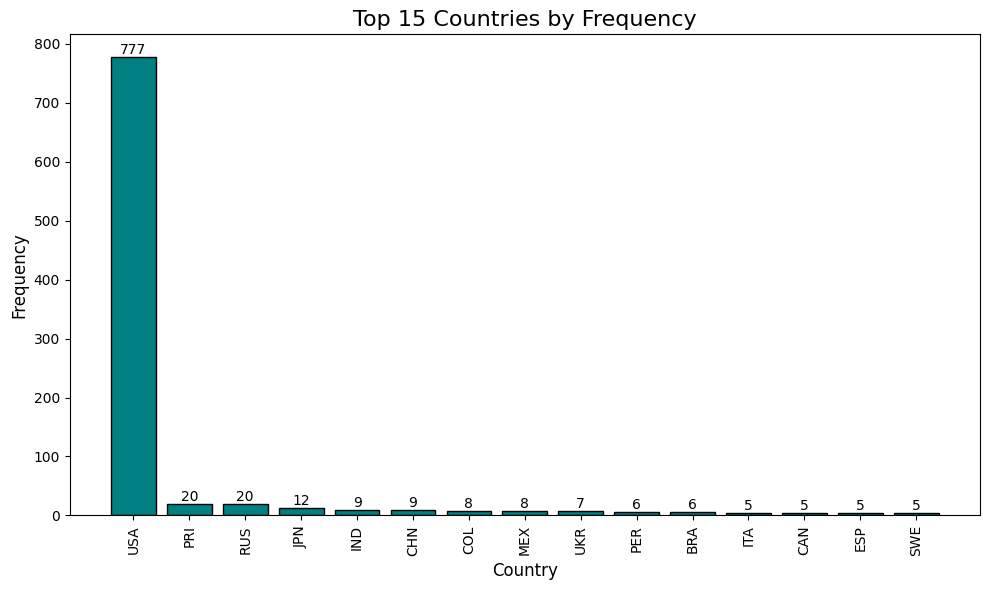

In [67]:
import matplotlib.pyplot as plt

# Count occurrences of each country_code
df_grouped = test_df['country_code'].value_counts().reset_index()
df_grouped.columns = ['country_code', 'count']

# Select the top 15 most frequent countries
df_top15 = df_grouped.head(15)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(df_top15['country_code'], df_top15['count'], color='teal', edgecolor='black')

# Add titles and labels
plt.title('Top 15 Countries by Frequency', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.xticks(rotation='vertical')
plt.ylabel('Frequency', fontsize=12)

# Annotate values on the bars
for index, value in enumerate(df_top15['count']):
    plt.text(index, value + 5, str(value), ha='center', fontsize=10)

# Show plot
plt.tight_layout()
plt.show()


# Imputation
Since death is our target variable and in our data it is maximum missing so we have to impute it best to make the dataset complete so that we can train the model.

We did using 2 approach-

  1.Imputation before features - this use only the Lat and Long data and advanced geospatial Algorithm to impute the data.

  2.Imputation before/after features - In this we used Randomforest imputer , by first training it on known deaths values ( since only lat and long data  so we can use it before features also but it is not performing well.) we first make feature and then train it.

After testing and experiments we observed that first approach is more accurate and well-suited with real-world solutions

## Imputation Before Features

Explaination of each algorithm is given the report.

### IDW

In [68]:
import pandas as pd
import numpy as np
from scipy.spatial import distance_matrix

# Assuming train_df is your DataFrame with 'latitude', 'longitude', and 'deaths' columns

# Separate known and unknown death values
known_deaths = train_df[train_df['Deaths'].notna()]
unknown_deaths = train_df[train_df['Deaths'].isna()]

# Compute distance matrix between known and unknown points
dist_matrix = distance_matrix(unknown_deaths[['Lat', 'Long_']], known_deaths[['Lat', 'Long_']])

# Apply IDW
def idw(distances, values, power=2):
    weights = 1 / np.power(distances, power)
    return np.sum(weights * values) / np.sum(weights)

# Impute missing values
imputed_values = []
for i in range(dist_matrix.shape[0]):
    distances = dist_matrix[i]
    values = known_deaths['Deaths'].values
    imputed_value = idw(distances, values)
    imputed_values.append(imputed_value)


# Create a new DataFrame with imputed values

train_df.loc[train_df['Deaths'].isna(), 'Deaths'] = imputed_values

### Ball Tree

In [69]:
# import pandas as pd
# import numpy as np
# from sklearn.neighbors import BallTree
# from math import radians

# def impute_deaths_spatial(df, k=5):
#     # Split into known and unknown deaths
#     known = df[df['Deaths'].notna()]
#     unknown = df[df['Deaths'].isna()]

#     if unknown.empty:
#         return df

#     # Build BallTree on known points (convert to radians)
#     tree = BallTree(known[['Lat', 'Long_']].applymap(radians), metric='haversine')

#     # Query unknown points
#     distances, indices = tree.query(unknown[['Lat', 'Long_']].applymap(radians), k=k)

#     # Impute mean of neighbors
#     imputed_deaths = known.iloc[indices.flatten()]['Deaths'].values.reshape(-1, k).mean(axis=1)
#     df.loc[unknown.index, 'Deaths'] = imputed_deaths
#     return df

# # Example usage:
# train_df = impute_deaths_spatial(train_df.copy())

### Kriging

In [70]:
# import numpy as np
# import pandas as pd
# from pykrige.ok import OrdinaryKriging
# import matplotlib.pyplot as plt

# def apply_kriging(df, latitude_col='latitude', longitude_col='longitude', target_col='deaths'):
#     """
#     Applies Ordinary Kriging to estimate missing values in the target column.

#     Parameters:
#         df (DataFrame): Input DataFrame with latitude, longitude, and target column.
#         latitude_col (str): Name of the column containing latitude values.
#         longitude_col (str): Name of the column containing longitude values.
#         target_col (str): Name of the column to estimate missing values.

#     Returns:
#         DataFrame: A DataFrame with estimated values filled for the target column.
#     """
#     # Separate known and missing values
#     known_data = df.dropna(subset=[target_col])
#     missing_data = df[df[target_col].isna()]

#     # Coordinates and values for known data
#     known_coords = known_data[[longitude_col, latitude_col]].values
#     known_values = known_data[target_col].values

#     # Coordinates for missing data
#     missing_coords = missing_data[[longitude_col, latitude_col]].values

#     # Apply Ordinary Kriging
#     kriging_model = OrdinaryKriging(
#         known_coords[:, 0],  # Longitude
#         known_coords[:, 1],  # Latitude
#         known_values,        # Known target values
#         variogram_model='gaussian',  # Variogram model ('linear', 'power', 'gaussian', etc.)
#         verbose=True,
#         enable_plotting=True,
#     )

#     # Predict missing values
#     z, ss = kriging_model.execute("points", missing_coords[:, 0], missing_coords[:, 1])

#     # Update the DataFrame with estimated values
#     df.loc[df[target_col].isna(), target_col] = z

#     # Return the updated DataFrame
#     return df

# # Example usage:
# # Apply Kriging on train_df
# train_df = apply_kriging(train_df, latitude_col='Lat', longitude_col='Long_', target_col='Deaths')

### Round off And some Visulizations

In [71]:
train_df["Deaths"] = train_df["Deaths"].round().astype("Int64")  # Keeps NaN values

In [72]:
# train_df.reset_index(drop=True, inplace=True)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3920 entries, 0 to 3919
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Lat                  3920 non-null   float64
 1   Long_                3920 non-null   float64
 2   Deaths               3920 non-null   Int64  
 3   Case_Fatality_Ratio  3920 non-null   float64
 4   country_code         3920 non-null   object 
dtypes: Int64(1), float64(3), object(1)
memory usage: 157.1+ KB


#### Analysing the Death after Imputations

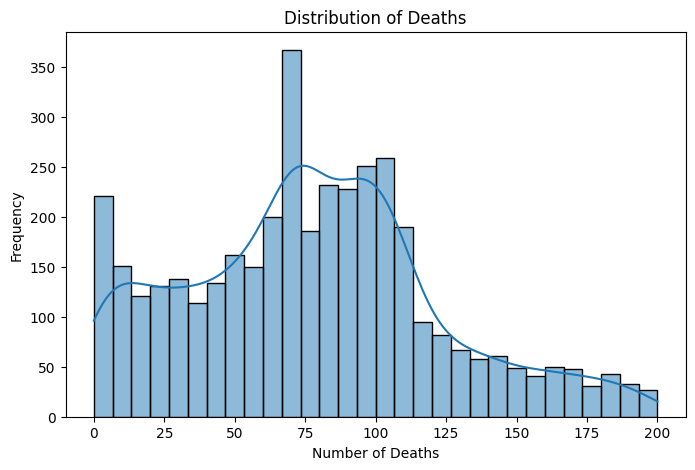

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop NaN values for visualization
deaths_data = train_df["Deaths"].dropna()

# Plot the distribution
plt.figure(figsize=(8, 5))
sns.histplot(deaths_data, bins=30, kde=True)

# Labels and title
plt.xlabel("Number of Deaths")
plt.ylabel("Frequency")
plt.title("Distribution of Deaths")

# Show plot
plt.show()


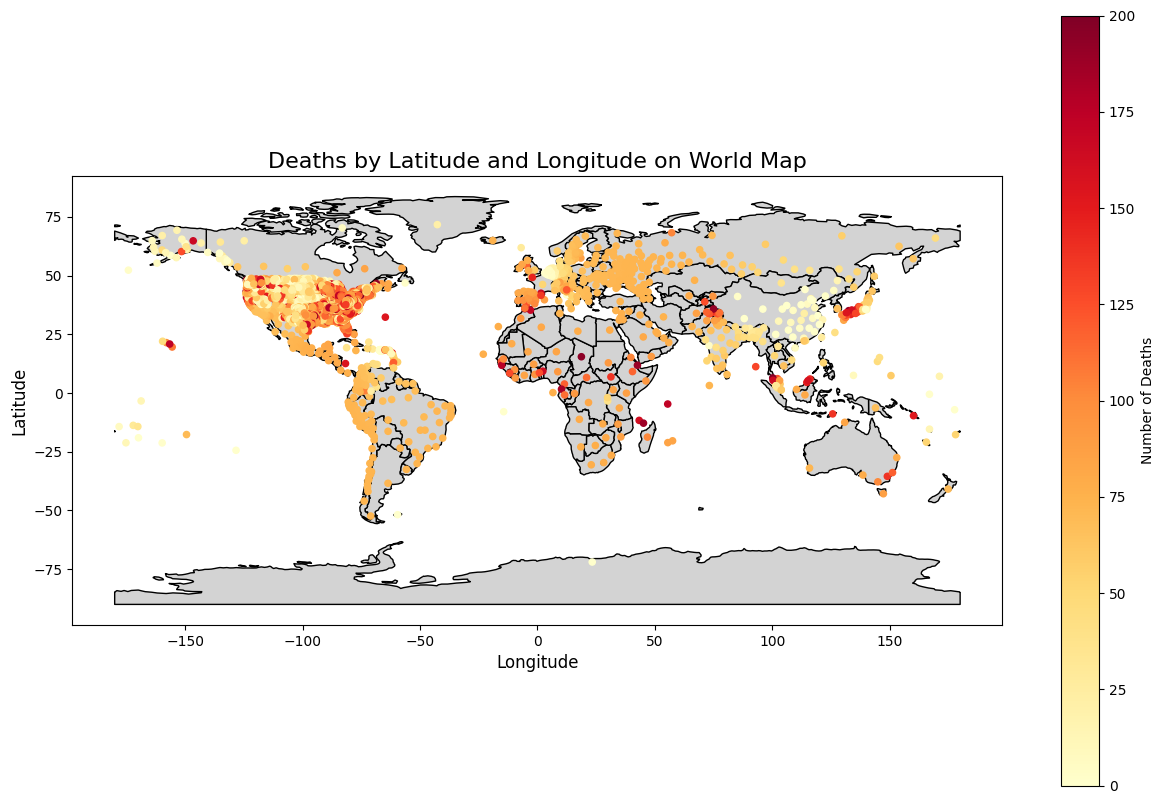

In [74]:
import geopandas as gpd

# Load the world map shapefile
# Download the naturalearth_lowres dataset
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)


# Create a GeoDataFrame for the points
gdf = gpd.GeoDataFrame(
    train_df,
    geometry=gpd.points_from_xy(train_df['Long_'], train_df['Lat'])
)

# Plot the world map
fig, ax = plt.subplots(figsize=(15, 10))
world.plot(ax=ax, color='lightgray', edgecolor='black')

# Plot the points on the map with a color gradient
scatter = gdf.plot(
    ax=ax,
    column='Deaths',  # Use 'Deaths' to determine the color
    cmap='YlOrRd',    # Color gradient from light yellow to dark red
    markersize=20,    # Fixed marker size
    legend=True,      # Add a legend
    legend_kwds={'label': "Number of Deaths"}
)

# Add titles and labels
plt.title('Deaths by Latitude and Longitude on World Map', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Show plot
plt.show()

## Imputing methods After Feature

As we discuss above we can use it in both ways before and after.
But after analysising this not perform good so we comment this code and will not use this.

If you want to use this then put it after feature engineering if you are using the features column or else if you are using only Lat and Long then uncomment it and then you are ready to go

### Random Forest

To use this first make the Spatial Features with different Radius and then impute it.



In [75]:
# def impute_deaths(df):
#     """Impute missing death values using advanced techniques."""
#     # Create a copy to avoid modifying the original DataFrame
#     df = df.copy()

#     # Reset index to handle non-contiguous or duplicate indices
#     df.reset_index(drop=True, inplace=True)

#     imputation_features = [
#         'Lat', 'Long_', 'Case_Fatality_Ratio', 'avg_temp',
#         'development_index', 'urban_proximity',
#         'nearby_deaths_mean_100km', 'nearby_deaths_max_100km',
#         'nearby_deaths_count_100km', 'nearby_cfr_mean_100km',
#         'nearby_deaths_mean_500km', 'nearby_deaths_max_500km',
#         'nearby_deaths_count_500km', 'nearby_cfr_mean_500km',
#         'nearby_deaths_mean_1000km', 'nearby_deaths_max_1000km',
#         'nearby_deaths_count_1000km', 'nearby_cfr_mean_1000km'
#     ]

#     # Check for missing values in imputation features
#     if df[imputation_features].isna().any().any():
#         raise ValueError("Imputation features contain missing values. Handle them first.")

#     # Split data into known and unknown deaths
#     known_deaths = df.dropna(subset=['Deaths']).copy()
#     unknown_deaths = df[df['Deaths'].isna()].copy()

#     if unknown_deaths.empty:
#         print("No missing Deaths to impute.")
#         return df

#     if known_deaths.empty:
#         raise ValueError("No training data available (all Deaths are missing).")

#     # Train the model
#     imputer_model = RandomForestRegressor(
#         n_estimators=100,
#         max_depth=10,
#         random_state=42
#     )
#     imputer_model.fit(known_deaths[imputation_features], known_deaths['Deaths'])

#     # Predict missing deaths
#     predicted_deaths = imputer_model.predict(unknown_deaths[imputation_features])

#     # Ensure no index mismatch
#     valid_indices = unknown_deaths.index.intersection(df.index)
#     df.loc[valid_indices, 'Deaths'] = predicted_deaths

#     return df



# Feature Engineering

Now we have the clean and complete dataset.
Next we will make the new features based on the research we did on the ebola like disease and geo-spatial dataset


##Temp Df

This is data of average surface temperature of each country.





In [76]:
ISC_temp2022 = [['AFG', 10.82], ['ALB', 13.75],
['DZA', 19.83],
['AND', 7.176],
['AGO', 22.69],
['ATG', 26.19],
['ARG', 15.6],
['ARM', 8.193],
['AUS', 19.01],
['AUT', 8.363],
['AZE', 12.56],
['BHS', 25.87],
['BHR', 26.62],
['BGD', 25.8],
['BRB', 26.35],
['BLR', 7.839],
['BEL', 11.59],
['BLZ', 26.0],
['BEN', 27.39],
['BTN', 11.08],
['BOL', 18.08],
['BIH', 11.61],
['BWA', 21.34],
['BRA', 24.21],
['BRN', 26.41],
['BGR', 12.25],
['BFA', 28.51],
['BDI', 20.9],
['CPV', 23.25],
['KHM', 27.5],
['CMR', 24.57],
['CAN', 0.6],
['CAF', 26.23],
['TCD', 27.86],
['CHL', 9.418],
['CHN', 13.25],
['COL', 22.79],
['COM', 25.46],
['COD', 24.27],
['COG', 25.02],
['CRI', 22.22],
['CIV', 26.47],
['HRV', 13.3],
['CUB', 25.82],
['CYP', 19.31],
['CZE', 9.636],
['DNK', 9.732],
['DJI', 28.69],
['DMA', 25.7],
['DOM', 24.27],
['ECU', 20.84],
['EGY', 22.44],
['SLV', 26.09],
['GNQ', 24.33],
['ERI', 25.4],
['EST', 6.864],
['SWZ', 19.62],
['ETH', 23.21],
['FJI', 25.08],
['FIN', 5.599],
['FRA', 14.26],
['PYF', 25.17],
['GAB', 25.03],
['GMB', 27.58],
['GEO', 8.962],
['DEU', 10.7],
['GHA', 27.32],
['GIB', 18.33],
['GRC', 16.09],
['GRL', -17.12],
['GRD', 26.48],
['GTM', 22.45],
['GIN', 26.13],
['GNB', 27.47],
['GUY', 25.44],
['HTI', 25.41],
['HND', 23.84],
['HUN', 12.34],
['ISL', 1.777],
['IND', 22.95],
['IDN', 25.58],
['IRN', 17.27],
['IRQ', 24.28],
['IRL', 10.52],
['IMN', 11.15],
['ISR', 20.45],
['ITA', 13.68],
['JAM', 26.07],
['JPN', 13.67],
['JEY', 13.26],
['JOR', 19.97],
['KAZ', 7.556],
['KEN', 23.11],
['KIR', 26.37],
['KOR', 13.25],
['XKO', 11.04],
['KWT', 27.13],
['KGZ', 3.033],
['LAO', 23.33],
['LVA', 7.334],
['LBN', 16.83],
['LSO', 11.73],
['LBR', 25.59],
['LBY', 22.45],
['LIE', 7.386],
['LTU', 7.878],
['LUX', 10.73],
['MDG', 21.89],
['MWI', 22.27],
['MYS', 26.48],
['MLI', 28.72],
['MRT', 28.79],
['MUS', 24.13],
['MEX', 20.91],
['FSM', 27.16],
['MDA', 11.38],
['MCO', 16.38],
['MNG', 0.791],
['MNE', 12.19],
['MAR', 19.47],
['MOZ', 23.99],
['MMR', 25.04],
['NAM', 22.14],
['NPL', 13.72],
['NLD', 11.53],
['NZL', 12.39],
['NIC', 25.64],
['NER', 28.04],
['NGA', 26.89],
['MKD', 11.79],
['NOR', 4.28],
['OMN', 28.09],
['PAK', 16.89],
['PRK', 7.43],
['PAN', 24.83],
['PNG', 23.0],
['PRY', 22.54],
['PER', 15.78],
['PHL', 26.34],
['POL', 9.577],
['PRT', 16.97],
['QAT', 28.25],
['ROU', 11.19],
['RUS', 2.845],
['RWA', 19.73],
['WSM', 25.31],
['SMR', 15.66],
['STP', 25.92],
['SAU', 26.58],
['SEN', 27.64],
['SRB', 12.44],
['SLE', 26.26],
['SGP', 27.25],
['SVK', 10.25],
['SVN', 11.43],
['SLB', 26.66],
['SOM', 26.91],
['ZAF', 17.95],
['SSD', 28.33],
['ESP', 15.56],
['LKA', 26.46],
['KNA', 26.19],
['LCA', 26.5],
['VCT', 26.37],
['SDN', 28.42],
['SUR', 26.14],
['SJM', -6.16],
['SWE', 6.425],
['CHE', 8.009],
['SYR', 19.09],
['TJK', 6.721],
['TZA', 23.77],
['THA', 26.89],
['TLS', 24.84],
['TGO', 27.12],
['TON', 25.52],
['TTO', 26.25],
['TUN', 20.72],
['TUR', 12.31],
['TKM', 17.35],
['TCA', 26.35],
['UGA', 23.2],
['UKR', 9.934],
['ARE', 28.85],
['GBR', 10.75],
['USA', 12.05],
['URY', 17.01],
['UZB', 13.91],
['VUT', 26.09],
['VAT', 17.2],
['VEN', 24.94],
['VNM', 24.82],
['PSE', 20.75],
['YEM', 24.12],
['ZMB', 22.04],
['ZWE', 21.05]]

temp_df = pd.DataFrame(ISC_temp2022, columns=['ISO_Code', '2022'])

## 1.Tempearture and Climate Featues

In [77]:
def add_climate_features(df):
    """Add enhanced climate and environmental features."""
    df = df.copy()
    avg_temp_map = dict(zip(temp_df["ISO_Code"], temp_df["2022"]))
    global_mean = temp_df['2022'].mean()
    # Initialize a new column with NaN
    df["2022 Avg Temp"] = None

    # Assign average temperature based on country code
    for i in range(len(df)):
        country_code = df.loc[i, "country_code"]
        if country_code in avg_temp_map:
            df.loc[i, "2022 Avg Temp"] = avg_temp_map[country_code]

        else:
          df.loc[i, "2022 Avg Temp"] = global_mean

    # df['temp_zone'] = pd.qcut(df['2022 Avg Temp'], q=5, labels=['very_cold', 'cold', 'moderate', 'warm', 'hot'])
    df['is_tropical'] = ((df['Lat'] >= -23.5) & (df['Lat'] <= 23.5)).astype(int)
    return df
train_df = add_climate_features(train_df)
test_df = add_climate_features(test_df)

## 2.Spatial and Cluster Features

### For Deaths Spatial Lag

In [78]:
def add_spatial_lag(df, radius_km=100):
    coords_rad = df[['Lat', 'Long_']].applymap(radians)
    tree = BallTree(coords_rad, metric='haversine')
    radius_rad = radius_km / 6371  # Earth radius in km

    spatial_lag = []
    for i in range(len(df)):
        point = coords_rad.iloc[i].values.reshape(1, -1)
        indices = tree.query_radius(point, r=radius_rad)[0]
        neighbors = df.iloc[indices]
        neighbors = neighbors[neighbors.index != df.index[i]]  # Exclude self
        spatial_lag.append(neighbors['Deaths'].mean() if not neighbors.empty else np.nan)

    df['spatial_lag'] = spatial_lag
    df['spatial_lag'].fillna(df['Deaths'].mean(), inplace=True)
    return df



def add_cluster_features(df, eps_km=200, min_samples=2):
    coords_rad = df[['Lat', 'Long_']].applymap(radians)
    eps_rad = eps_km / 6371  # Convert radius to radians

    # Cluster using DBSCAN
    db = DBSCAN(eps=eps_rad, min_samples=min_samples, metric='haversine').fit(coords_rad)
    df['cluster_label'] = db.labels_

    # Compute cluster mean deaths
    cluster_means = df.groupby('cluster_label')['Deaths'].mean().to_dict()

    # Map cluster mean deaths to the DataFrame
    df['cluster_mean_deaths'] = df['cluster_label'].map(cluster_means)

    # Handle noise points (-1 label) by setting them to the original deaths value
    df.loc[df['cluster_label'] == -1, 'cluster_mean_deaths'] = df['Deaths']

    return df

def add_spatial_lag_test(test_df, train_df, radius_km=100):
    train_coords_rad = train_df[['Lat', 'Long_']].applymap(radians)
    tree = BallTree(train_coords_rad, metric='haversine')
    radius_rad = radius_km / 6371

    spatial_lag = []
    for i in range(len(test_df)):
        point = np.radians([[test_df.iloc[i]['Lat'], test_df.iloc[i]['Long_']]])
        indices = tree.query_radius(point, r=radius_rad)[0]
        neighbors = train_df.iloc[indices]
        spatial_lag.append(neighbors['Deaths'].mean() if not neighbors.empty else np.nan)

    test_df['spatial_lag'] = spatial_lag
    test_df['spatial_lag'].fillna(train_df['Deaths'].mean(), inplace=True)
    return test_df

def add_cluster_features_test(test_df, train_df):
    # Assign test points to the nearest cluster in train
    train_coords_rad = train_df[['Lat', 'Long_']].applymap(radians)
    tree = BallTree(train_coords_rad, metric='haversine')

    # Find nearest training point for each test point
    distances, indices = tree.query(np.radians(test_df[['Lat', 'Long_']]), k=1)
    test_df['cluster_label'] = train_df.iloc[indices.flatten()]['cluster_label'].values
    cluster_means = train_df.groupby('cluster_label')['Deaths'].mean().to_dict()
    test_df['cluster_mean_deaths'] = test_df['cluster_label'].map(cluster_means)
    test_df['cluster_mean_deaths'].fillna(train_df['Deaths'].mean(), inplace=True)
    return test_df



In [79]:
train_df = add_spatial_lag(train_df)
test_df = add_spatial_lag_test(test_df,train_df)

train_df = add_cluster_features(train_df)
test_df = add_cluster_features_test(test_df,train_df)

<ipython-input-78-30dd7a88f09c>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  coords_rad = df[['Lat', 'Long_']].applymap(radians)
<ipython-input-78-30dd7a88f09c>:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['spatial_lag'].fillna(df['Deaths'].mean(), inplace=True)
<ipython-input-78-30dd7a88f09c>:40: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  train_coords_rad = train_df[['Lat', 'Long_']].applymap(radians)
<ipython-input-78-30dd7a88f09c>:52:

### For CFR Spatial lag

In [80]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from sklearn.neighbors import BallTree
from math import radians
from sklearn.cluster import DBSCAN

# Function to compute spatial lag based on Case Fatality Ratio (CFR)
def add_spatial_lag(df, radius_km=100):
    coords_rad = df[['Lat', 'Long_']].applymap(radians)
    tree = BallTree(coords_rad, metric='haversine')
    radius_rad = radius_km / 6371  # Convert km to Earth-radius in radians

    spatial_lag_cfr = []
    for i in range(len(df)):
        point = coords_rad.iloc[i].values.reshape(1, -1)
        indices = tree.query_radius(point, r=radius_rad)[0]
        neighbors = df.iloc[indices]
        neighbors = neighbors[neighbors.index != df.index[i]]  # Exclude self
        spatial_lag_cfr.append(neighbors['Case_Fatality_Ratio'].mean() if not neighbors.empty else np.nan)

    df['spatial_lag_CFR'] = spatial_lag_cfr
    df['spatial_lag_CFR'].fillna(df['Case_Fatality_Ratio'].mean(), inplace=True)
    return df

# Function to compute cluster-based CFR features
def add_cluster_features(df, eps_km=200, min_samples=2):
    coords_rad = df[['Lat', 'Long_']].applymap(radians)
    eps_rad = eps_km / 6371  # Convert radius to radians

    # Cluster using DBSCAN
    db = DBSCAN(eps=eps_rad, min_samples=min_samples, metric='haversine').fit(coords_rad)
    df['cluster_label'] = db.labels_

    # Compute cluster mean CFR
    cluster_means = df.groupby('cluster_label')['Case_Fatality_Ratio'].mean().to_dict()

    # Map cluster mean CFR to the DataFrame
    df['cluster_mean_CFR'] = df['cluster_label'].map(cluster_means)

    # Handle noise points (-1 label) by setting them to the original CFR value
    df.loc[df['cluster_label'] == -1, 'cluster_mean_CFR'] = df['Case_Fatality_Ratio']

    return df

# Function to compute spatial lag for test data using train data
def add_spatial_lag_test(test_df, train_df, radius_km=100):
    train_coords_rad = train_df[['Lat', 'Long_']].applymap(radians)
    tree = BallTree(train_coords_rad, metric='haversine')
    radius_rad = radius_km / 6371  # Convert km to Earth-radius in radians

    spatial_lag_cfr = []
    for i in range(len(test_df)):
        point = np.radians([[test_df.iloc[i]['Lat'], test_df.iloc[i]['Long_']]])
        indices = tree.query_radius(point, r=radius_rad)[0]
        neighbors = train_df.iloc[indices]
        spatial_lag_cfr.append(neighbors['Case_Fatality_Ratio'].mean() if not neighbors.empty else np.nan)

    test_df['spatial_lag_CFR'] = spatial_lag_cfr
    test_df['spatial_lag_CFR'].fillna(train_df['Case_Fatality_Ratio'].mean(), inplace=True)
    return test_df

# Function to assign test data to clusters based on nearest train cluster
def add_cluster_features_test(test_df, train_df):
    train_coords_rad = train_df[['Lat', 'Long_']].applymap(radians)
    tree = BallTree(train_coords_rad, metric='haversine')

    # Find nearest training point for each test point
    distances, indices = tree.query(np.radians(test_df[['Lat', 'Long_']]), k=1)
    test_df['cluster_label'] = train_df.iloc[indices.flatten()]['cluster_label'].values

    # Compute cluster mean CFR
    cluster_means = train_df.groupby('cluster_label')['Case_Fatality_Ratio'].mean().to_dict()
    test_df['cluster_mean_CFR'] = test_df['cluster_label'].map(cluster_means)

    # Handle missing cluster assignments
    test_df['cluster_mean_CFR'].fillna(train_df['Case_Fatality_Ratio'].mean(), inplace=True)

    return test_df


In [81]:
train_df = add_spatial_lag(train_df)
test_df = add_spatial_lag_test(test_df,train_df)

train_df = add_cluster_features(train_df)
test_df = add_cluster_features_test(test_df,train_df)

<ipython-input-80-ca6ad899e8c3>:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  coords_rad = df[['Lat', 'Long_']].applymap(radians)
<ipython-input-80-ca6ad899e8c3>:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['spatial_lag_CFR'].fillna(df['Case_Fatality_Ratio'].mean(), inplace=True)
<ipython-input-80-ca6ad899e8c3>:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  train_coords_rad = train_df[['Lat', 'Long_']].applymap(radians)
<ipython-input-80

## 3.Spatial Density Feature

In [82]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# Function to add spatial_density to DataFrame
def add_density_feature_columns_to_dataframe(df: pd.DataFrame, radius: float = 10) -> pd.DataFrame:
    # Create KD-tree with latitude and longitude
    tree = cKDTree(df[['Lat', 'Long_']])

    # Apply spatial query to find number of points within a given radius
    spatial_density = [
        len(tree.query_ball_point(point, radius)) - 1  # Subtract 1 to exclude the point itself
        for point in df[['Lat', 'Long_']].values
    ]

    # Add spatial_density as a new column in the DataFrame
    df['spatial_density'] = spatial_density
    return df


In [83]:
train_df = add_density_feature_columns_to_dataframe(train_df)
test_df = add_density_feature_columns_to_dataframe(test_df)

## Analysing the new features

In [84]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3920 entries, 0 to 3919
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Lat                  3920 non-null   float64
 1   Long_                3920 non-null   float64
 2   Deaths               3920 non-null   Int64  
 3   Case_Fatality_Ratio  3920 non-null   float64
 4   country_code         3920 non-null   object 
 5   2022 Avg Temp        3920 non-null   object 
 6   is_tropical          3920 non-null   int64  
 7   spatial_lag          3920 non-null   float64
 8   cluster_label        3920 non-null   int64  
 9   cluster_mean_deaths  3920 non-null   float64
 10  spatial_lag_CFR      3920 non-null   float64
 11  cluster_mean_CFR     3920 non-null   float64
 12  spatial_density      3920 non-null   int64  
dtypes: Int64(1), float64(7), int64(3), object(2)
memory usage: 402.1+ KB


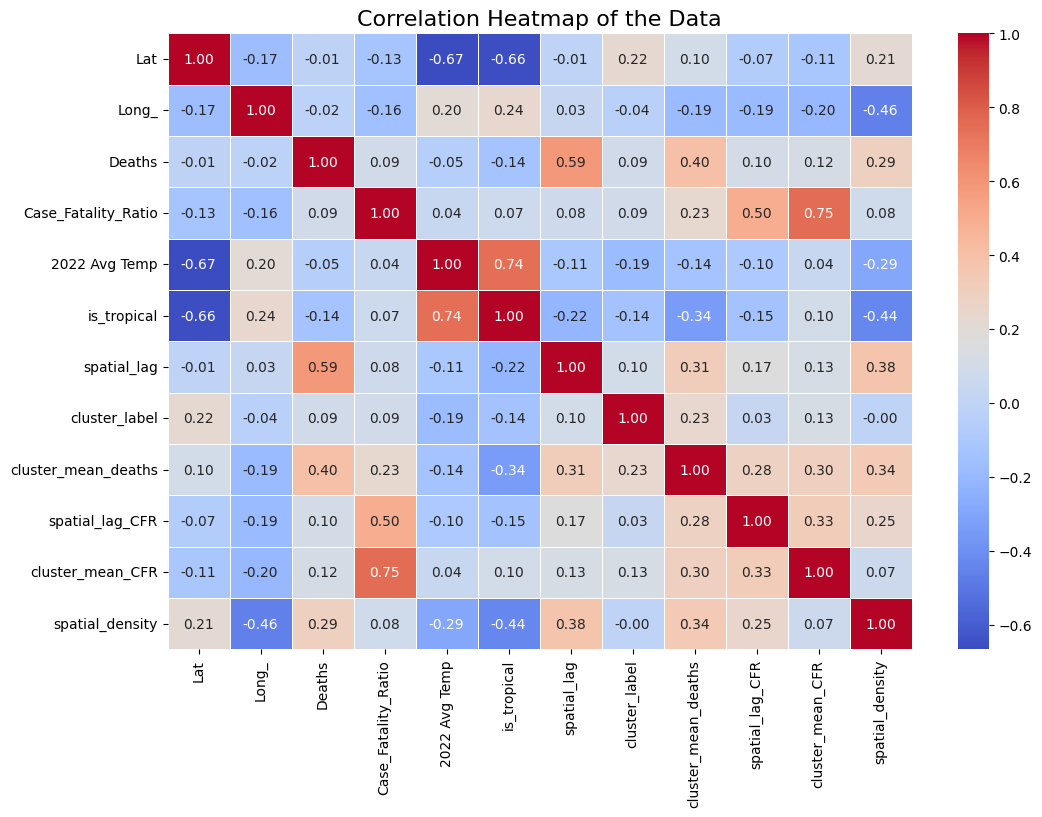

In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame
# Exclude the 'country_code' column and any non-numeric columns
df_numeric = train_df.drop(columns=['country_code'])

# Compute the correlation matrix
corr_matrix = df_numeric.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Create a heatmap of the correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Add title and display the plot
plt.title('Correlation Heatmap of the Data', fontsize=16)
plt.show()


# Model Training

We created Separate models to predict Deaths and CFR.
And make the Machince Learning Model and Deep Learning Models

We split the training the data into train_test_split as 0.2.


We conduct various experiment with each imputations techniques and find the various results like best model, best set of features and thier rmse score.

## Death Model

### Features Columns

In [86]:
train_df.columns,test_df.columns

(Index(['Lat', 'Long_', 'Deaths', 'Case_Fatality_Ratio', 'country_code',
        '2022 Avg Temp', 'is_tropical', 'spatial_lag', 'cluster_label',
        'cluster_mean_deaths', 'spatial_lag_CFR', 'cluster_mean_CFR',
        'spatial_density'],
       dtype='object'),
 Index(['Lat', 'Long_', 'country_code', '2022 Avg Temp', 'is_tropical',
        'spatial_lag', 'cluster_label', 'cluster_mean_deaths',
        'spatial_lag_CFR', 'cluster_mean_CFR', 'spatial_density'],
       dtype='object'))

This is best features we got from our experiments

In [87]:
# Define feature columns
feature_columns = [
        'Lat', 'Long_',
         '2022 Avg Temp',
        'cluster_mean_deaths',
    ]

### Scaling

In [88]:
# Scale features
scaler = StandardScaler()
X_train = train_df[feature_columns]
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_columns
)

X_test = test_df[feature_columns]
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_columns
)

In [89]:
# Train models
print("\nTraining models...")
target_columns= 'Deaths'
# Death prediction
death_mask = train_df[target_columns].notna()
X_death = X_train_scaled[death_mask]
y_death = train_df.loc[death_mask, target_columns]
# Split data
X_train_death, X_val_death, y_train_death, y_val_death = train_test_split(
    X_death, y_death, test_size=0.1, random_state=42
)




Training models...


### Machince Learning Models

#### Finding best model

In [90]:
from sklearn.metrics import mean_squared_error
import math
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, BaggingRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# Define models
models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'LinearRegression': LinearRegression(),
    'Lasso': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'Ridge': Ridge(alpha=1.0),
    'KNeighbors': KNeighborsRegressor(n_neighbors=5),
    'Bagging_DecisionTree': BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=50, random_state=42),
    'Bagging_XGBoost': BaggingRegressor(estimator=xgb.XGBRegressor(n_estimators=50), n_estimators=50, random_state=42),
    'Bagging_KNeighbors': BaggingRegressor(estimator=KNeighborsRegressor(n_neighbors=5), n_estimators=50, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),
    'SVM': SVR(kernel='rbf', C=100, epsilon=0.1)
}

# Apply scaling
scaler = StandardScaler()
X_train_death_scaled = scaler.fit_transform(X_train_death)
X_val_death_scaled = scaler.transform(X_val_death)

# Dictionary to store RMSE values
model_rmse = {}

# Train and evaluate each model
for model_name, model in models.items():
    # Train model
    model.fit(X_train_death_scaled, y_train_death)

    # Predict on validation set
    y_pred_val = model.predict(X_val_death_scaled)

    # Compute RMSE
    rmse = math.sqrt(mean_squared_error(y_val_death, y_pred_val))

    # Store RMSE
    model_rmse[model_name] = rmse

# Find the best model with lowest RMSE
best_model_name = min(model_rmse, key=model_rmse.get)
best_rmse = model_rmse[best_model_name]

# Print best model
print(model_rmse)
print(f"Best Model: {best_model_name}")
print(f"Best RMSE: {best_rmse:.2f}")


{'RandomForest': 31.691727731896425, 'XGBoost': 34.085739635284064, 'GradientBoosting': 32.48950434353978, 'LinearRegression': 38.38695178456765, 'Lasso': 38.3964617952742, 'ElasticNet': 38.43226382659095, 'Ridge': 38.3871215056043, 'KNeighbors': 32.025162301043274, 'Bagging_DecisionTree': 31.909514878730423, 'Bagging_XGBoost': 31.148416925312993, 'Bagging_KNeighbors': 32.284440945180656, 'AdaBoost': 35.460044727727066, 'SVM': 36.28662774242088}
Best Model: Bagging_XGBoost
Best RMSE: 31.15


#### Finding best combination of features for above best model

In [91]:
# from itertools import combinations
# from sklearn.metrics import mean_squared_error
# import math
# import numpy as np
# import xgboost as xgb
# from xgboost import XGBRegressor

# # List of features
# all_features = feature_columns

# # Generate all possible feature combinations
# feature_combinations = []
# for r in range(1, len(all_features) + 1):
#     feature_combinations.extend(combinations(all_features, r))

# # Dictionary to store RMSE results for each combination
# combination_rmse = {}

# # Define the model
# death_model = models[best_model_name]

# # Evaluate feature combinations
# for feature_comb in feature_combinations:
#     # Select features for this combination
#     X_train_comb = X_train_death[list(feature_comb)]
#     X_val_comb = X_val_death[list(feature_comb)]

#     # Apply scaling
#     X_train_comb_scaled = scaler.fit_transform(X_train_comb)
#     X_val_comb_scaled = scaler.transform(X_val_comb)

#     # Train the model
#     death_model.fit(X_train_comb_scaled, y_train_death)

#     # Predict validation set
#     y_pred_val = death_model.predict(X_val_comb_scaled)

#     # Compute RMSE
#     rmse = math.sqrt(mean_squared_error(y_val_death, y_pred_val))
#     combination_rmse[feature_comb] = rmse

# # Find the best feature combination (lowest RMSE)
# best_features, best_rmse = min(combination_rmse.items(), key=lambda x: x[1])
# print(f"Best Feature Set: {best_features}, RMSE: {best_rmse:.2f}")

# # Train final death model with the best features
# X_train_best = X_train_death[list(best_features)]
# X_val_best = X_val_death[list(best_features)]

# X_train_best_scaled = scaler.fit_transform(X_train_best)
# X_val_best_scaled = scaler.transform(X_val_best)

# # Train on best feature set
# death_model.fit(X_train_best_scaled, y_train_death)

# # Final prediction and RMSE
# death_pred_val = death_model.predict(X_val_best_scaled)
# death_rmse = np.sqrt(mean_squared_error(y_val_death, death_pred_val))
# print(f"Final Death Prediction RMSE: {death_rmse:.2f}")


#### Combine both best model with best feature combinations
This may take more than 5 minutes

In [92]:
# from itertools import combinations
# from sklearn.metrics import mean_squared_error
# import math
# import numpy as np
# import xgboost as xgb
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, BaggingRegressor
# from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.preprocessing import StandardScaler

# # List of features
# all_features = feature_columns

# # Generate all possible feature combinations
# feature_combinations = []
# for r in range(1, len(all_features) + 1):
#     feature_combinations.extend(combinations(all_features, r))

# # Dictionary to store RMSE results for each model and feature set
# combination_rmse = {}

# # Define models
# models = {
#     'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
#     'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42),
#     'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
#     'Bagging_XGBoost': BaggingRegressor(estimator=xgb.XGBRegressor(n_estimators=50), n_estimators=50, random_state=42),
# }

# scaler = StandardScaler()  # Scaling features

# # Iterate through all feature combinations
# for feature_comb in feature_combinations:
#     # Select features for the current combination
#     X_train_comb = X_train_death[list(feature_comb)]
#     X_val_comb = X_val_death[list(feature_comb)]

#     # Apply scaling
#     X_train_comb_scaled = scaler.fit_transform(X_train_comb)
#     X_val_comb_scaled = scaler.transform(X_val_comb)

#     # Train and evaluate each model
#     for model_name, model in models.items():
#         # Train the model
#         model.fit(X_train_comb_scaled, y_train_death)

#         # Make predictions
#         y_pred_val = model.predict(X_val_comb_scaled)

#         # Calculate RMSE
#         rmse = math.sqrt(mean_squared_error(y_val_death, y_pred_val))

#         # Store RMSE for the current model and feature combination
#         combination_rmse[(model_name, feature_comb)] = rmse

# # Sort RMSE values and get the best model + feature combination
# best_model, best_features = min(combination_rmse.items(), key=lambda x: x[1])
# best_model_name, best_feature_set = best_model
# best_rmse = combination_rmse[(best_model_name, best_feature_set)]

# # Print best model and feature combination
# print(f"Best Model: {best_model_name}")
# print(f"Best Feature Set: {best_feature_set}")
# print(f"Best RMSE: {best_rmse:.2f}")

# # Train the final model with the best features
# X_train_best = X_train_death[list(best_feature_set)]
# X_val_best = X_val_death[list(best_feature_set)]

# X_train_best_scaled = scaler.fit_transform(X_train_best)
# X_val_best_scaled = scaler.transform(X_val_best)

# final_model = models[best_model_name]
# final_model.fit(X_train_best_scaled, y_train_death)

# # Final prediction and RMSE
# final_pred_val = final_model.predict(X_val_best_scaled)
# final_rmse = np.sqrt(mean_squared_error(y_val_death, final_pred_val))
# print(f"Final Model RMSE: {final_rmse:.2f}")


### Deep Learning Models

#### Simple Neural Network Architectures.

In [93]:
# Convert the 'Deaths' column to float64 in both train_df and test_df
train_df['Deaths'] = train_df['Deaths'].astype('float64')

In [94]:
# Scale features
scaler = StandardScaler()
X_train = train_df[feature_columns]
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_columns
)

X_test = test_df[feature_columns]
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_columns
)

# Train models
print("\nTraining models...")
target_columns= 'Deaths'
# Death prediction
death_mask = train_df[target_columns].notna()
X_death = X_train_scaled[death_mask]
y_death = train_df.loc[death_mask, target_columns]
# Split data
X_train_death, X_val_death, y_train_death, y_val_death = train_test_split(
    X_death, y_death, test_size=0.2, random_state=42
)



Training models...


In [95]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Input, LeakyReLU
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1_l2

# Define input shape
input_dim = X_train_scaled.shape[1]
inputs = Input(shape=(input_dim,))

# Simple feedforward layers
x = Dense(128, activation=None, kernel_regularizer=l1_l2(1e-5, 1e-4))(inputs)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)
x = Dropout(0.3)(x)

x = Dense(64, activation=None, kernel_regularizer=l1_l2(1e-5, 1e-4))(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)
x = Dropout(0.2)(x)

x = Dense(32, activation=None, kernel_regularizer=l1_l2(1e-5, 1e-4))(x)
x = LeakyReLU(alpha=0.1)(x)

# Output layer
outputs = Dense(1)(x)

# Create and compile the model
simple_death_model = Model(inputs=inputs, outputs=outputs)
simple_death_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='huber',
    metrics=['mse', 'mae']
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]


# Train the model
history = simple_death_model.fit(
    X_train_death,
    y_train_death,
    validation_data=(X_val_death, y_val_death),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/200


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 74.5524 - mae: 75.0253 - mse: 7698.4067 - val_loss: 68.5951 - val_mae: 69.0612 - val_mse: 6584.2646 - learning_rate: 0.0010
Epoch 2/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 50.7417 - mae: 51.2103 - mse: 4196.6890 - val_loss: 38.3627 - val_mae: 38.8279 - val_mse: 2386.2583 - learning_rate: 0.0010
Epoch 3/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 31.4902 - mae: 31.9515 - mse: 1783.4563 - val_loss: 29.2411 - val_mae: 29.7045 - val_mse: 1544.0005 - learning_rate: 0.0010
Epoch 4/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 30.7768 - mae: 31.2358 - mse: 1721.8551 - val_loss: 28.3681 - val_mae: 28.8259 - val_mse: 1485.9071 - learning_rate: 0.0010
Epoch 5/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 30.6720 - mae: 31.1330 - mse: 1743.0955 - val_loss: 26.8793 - val_mae: 27.3368 - val_mse: 1419.1646 - learning_rate: 0.0010
Epoch 6/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 30.7817 - mae: 31.2421 - mse: 1717.5

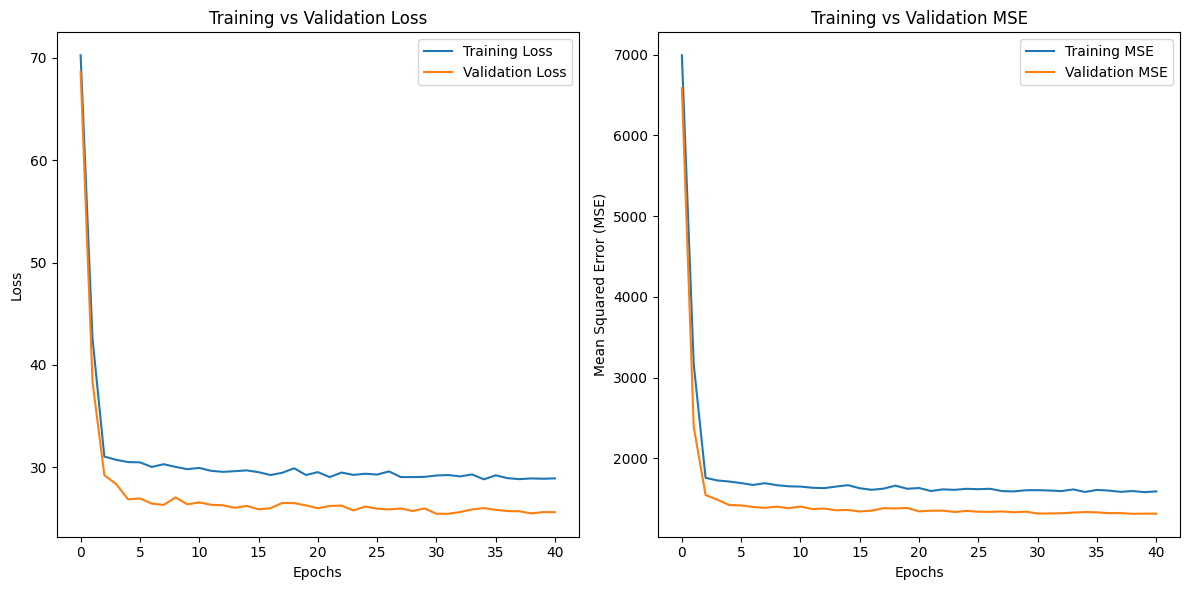

In [96]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.figure(figsize=(12, 6))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot mean squared error (if available)
plt.subplot(1, 2, 2)
plt.plot(history.history['mse'], label='Training MSE')
plt.plot(history.history['val_mse'], label='Validation MSE')
plt.title('Training vs Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()

plt.tight_layout()
plt.show()


In [97]:
death_pred_val = simple_death_model.predict(X_val_death).flatten()
death_rmse = np.sqrt(mean_squared_error(y_val_death, death_pred_val))
print("\nModel Evaluation Results:")
print(f"CFR Prediction RMSE: {death_rmse:.2f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Model Evaluation Results:
CFR Prediction RMSE: 36.25


#### Advanced - With Residual Blocks

In [98]:

# Scale features
scaler = StandardScaler()
X_train = train_df[feature_columns]
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_columns
)

X_test = test_df[feature_columns]
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_columns
)

# Train models
print("\nTraining models...")
target_columns= 'Deaths'
# Death prediction
death_mask = train_df[target_columns].notna()
X_death = X_train_scaled[death_mask]
y_death = train_df.loc[death_mask, target_columns]
# Split data
X_train_death, X_val_death, y_train_death, y_val_death = train_test_split(
    X_death, y_death, test_size=0.2, random_state=42
)



Training models...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - loss: 57.6883 - mae: 58.0839 - mse: 5169.0684 - val_loss: 33.6002 - val_mae: 33.9952 - val_mse: 1870.7744 - learning_rate: 0.0010
Epoch 2/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 33.0117 - mae: 33.4055 - mse: 1885.2380 - val_loss: 29.4499 - val_mae: 29.8437 - val_mse: 1581.1067 - learning_rate: 0.0010
Epoch 3/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 30.2320 - mae: 30.6217 - mse: 1648.2379 - val_loss: 28.1321 - val_mae: 28.5222 - val_mse: 1484.0530 - learning_rate: 0.0010
Epoch 4/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 30.4409 - mae: 30.8287 - mse: 1668.4421 - val_loss: 26.7200 - val_mae: 27.1042 - val_mse: 1379.6219 - learning_rate: 0.0010
Epoch 5/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 29.9149 - mae: 30.3056 - mse: 1680.0739 - val_loss: 26.2430 - val_mae: 26.6284 - val_mse: 1353.3541 - learning_rate: 0.0010
Epoch 6/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 30.3218 - mae: 30.709

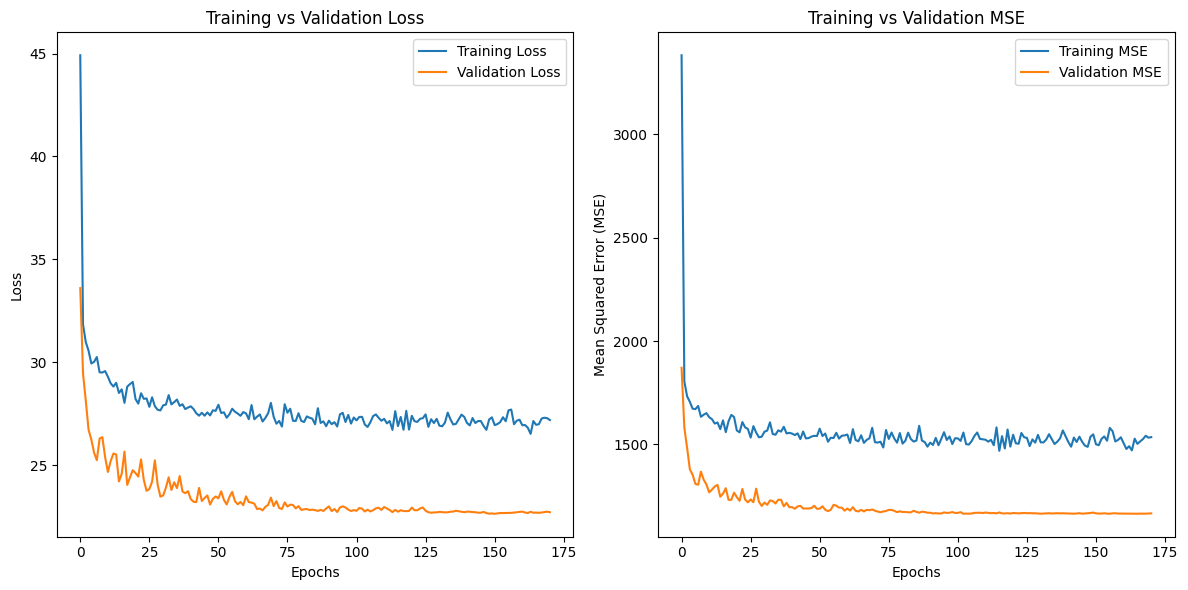

In [99]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Input,
    Concatenate, LeakyReLU, Add, LayerNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1_l2
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler
import numpy as np
import math
import matplotlib.pyplot as plt

# Build the enhanced Neural Network model
input_dim = X_train_scaled.shape[1]
inputs = Input(shape=(input_dim,))

# Deep branch
x1 = Dense(256, kernel_regularizer=l1_l2(1e-5, 1e-4))(inputs)
x1 = BatchNormalization()(x1)
x1 = LeakyReLU(alpha=0.1)(x1)
x1 = Dropout(0.3)(x1)

# Residual block 1
skip1 = x1
x1 = Dense(128, kernel_regularizer=l1_l2(1e-5, 1e-4))(x1)
x1 = LayerNormalization()(x1)
x1 = LeakyReLU(alpha=0.1)(x1)
x1 = Dropout(0.3)(x1)
x1 = Dense(128, kernel_regularizer=l1_l2(1e-5, 1e-4))(x1)
x1 = LayerNormalization()(x1)
skip1 = Dense(128)(skip1)
x1 = Add()([x1, skip1])
x1 = LeakyReLU(alpha=0.1)(x1)

# Residual block 2
skip2 = x1
x1 = Dense(64, kernel_regularizer=l1_l2(1e-5, 1e-4))(x1)
x1 = LayerNormalization()(x1)
x1 = LeakyReLU(alpha=0.1)(x1)
x1 = Dropout(0.2)(x1)
x1 = Dense(64, kernel_regularizer=l1_l2(1e-5, 1e-4))(x1)
x1 = LayerNormalization()(x1)
skip2 = Dense(64)(skip2)
x1 = Add()([x1, skip2])
x1 = LeakyReLU(alpha=0.1)(x1)

# Shallow branch for linear patterns
x2 = Dense(32, kernel_regularizer=l1_l2(1e-5, 1e-4))(inputs)
x2 = LeakyReLU(alpha=0.1)(x2)

# Combine branches
combined = Concatenate()([x1, x2])

# Final layers
x = Dense(32, kernel_regularizer=l1_l2(1e-5, 1e-4))(combined)
x = LeakyReLU(alpha=0.1)(x)
x = Dropout(0.15)(x)

outputs = Dense(1)(x)

cfr_model = Model(inputs=inputs, outputs=outputs)

# Compile with Huber loss for robustness to outliers
optimizer = Adam(learning_rate=0.001)
cfr_model.compile(
    optimizer=optimizer,
    loss='huber',
    metrics=['mse', 'mae']
)

# Prepare callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    )
]

# Train the model
history = cfr_model.fit(
    X_train_death,
    y_train_death,
    validation_data=(X_val_death, y_val_death),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

import matplotlib.pyplot as plt

# Plot training & validation loss
plt.figure(figsize=(12, 6))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot mean squared error (if available)
plt.subplot(1, 2, 2)
plt.plot(history.history['mse'], label='Training MSE')
plt.plot(history.history['val_mse'], label='Validation MSE')
plt.title('Training vs Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()

plt.tight_layout()
plt.show()




In [100]:
death_pred_val = cfr_model.predict(X_val_death).flatten()
death_rmse = np.sqrt(mean_squared_error(y_val_death, death_pred_val))
print("\nModel Evaluation Results:")
print(f"CFR Prediction RMSE: {death_rmse:.2f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

Model Evaluation Results:
CFR Prediction RMSE: 34.16


## CFR Model

In [101]:
train_df.columns,test_df.columns

(Index(['Lat', 'Long_', 'Deaths', 'Case_Fatality_Ratio', 'country_code',
        '2022 Avg Temp', 'is_tropical', 'spatial_lag', 'cluster_label',
        'cluster_mean_deaths', 'spatial_lag_CFR', 'cluster_mean_CFR',
        'spatial_density'],
       dtype='object'),
 Index(['Lat', 'Long_', 'country_code', '2022 Avg Temp', 'is_tropical',
        'spatial_lag', 'cluster_label', 'cluster_mean_deaths',
        'spatial_lag_CFR', 'cluster_mean_CFR', 'spatial_density'],
       dtype='object'))

This is the best Features we got after performing a large number of experiments and combinations

In [118]:
# Define feature columns
feature_columns = [
        'cluster_mean_CFR',
        'spatial_lag_CFR',
        'spatial_density',

    ]

In [119]:
# Scale features
scaler = StandardScaler()
X_train = train_df[feature_columns]
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_columns
)

X_test = test_df[feature_columns]
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_columns
)

In [120]:
target_col = 'Case_Fatality_Ratio'
# CFR prediction
cfr_mask = train_df[target_col].notna()
X_cfr = X_train_scaled[cfr_mask]
y_cfr = train_df.loc[cfr_mask, target_col]

X_train_cfr, X_val_cfr, y_train_cfr, y_val_cfr = train_test_split(
    X_cfr, y_cfr, test_size=0.1, random_state=42
)

### Machince Learning Models

In [121]:
from sklearn.metrics import mean_squared_error
import math
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, BaggingRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR



# Define models
models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'LinearRegression': LinearRegression(),
    'Lasso': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'Ridge': Ridge(alpha=1.0),
    'KNeighbors': KNeighborsRegressor(n_neighbors=5),
    'Bagging_DecisionTree': BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=50, random_state=42),
    'Bagging_XGBoost': BaggingRegressor(estimator=xgb.XGBRegressor(n_estimators=50), n_estimators=50, random_state=42),
    'Bagging_KNeighbors': BaggingRegressor(estimator=KNeighborsRegressor(n_neighbors=5), n_estimators=50, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),
    'SVM': SVR(kernel='rbf', C=100, epsilon=0.1)
}


# Apply scaling
scaler = StandardScaler()
X_train_cfr_scaled = scaler.fit_transform(X_train_cfr)
X_val_cfr_scaled = scaler.transform(X_val_cfr)

# Dictionary to store RMSE values
model_rmse = {}

# Train and evaluate each model
for model_name, model in models.items():
    # Train model
    model.fit(X_train_cfr_scaled, y_train_cfr)

    # Predict on validation set
    y_pred_val = model.predict(X_val_cfr_scaled)

    # Compute RMSE
    rmse = math.sqrt(mean_squared_error(y_val_cfr, y_pred_val))  # Fixed variable name

    # Store RMSE
    model_rmse[model_name] = rmse

# Find the best model with lowest RMSE
best_model_name = min(model_rmse, key=model_rmse.get)
best_rmse = model_rmse[best_model_name]

# Print results
print(model_rmse)
print(f"Best Model: {best_model_name}")
print(f"Best RMSE: {best_rmse:.2f}")

{'RandomForest': 0.5313059435779427, 'XGBoost': 0.5711727419690947, 'GradientBoosting': 0.49057512593604974, 'LinearRegression': 0.5080838709752803, 'Lasso': 0.5155287391593011, 'ElasticNet': 0.5108232525041695, 'Ridge': 0.5080778552860226, 'KNeighbors': 0.5160782378310856, 'Bagging_DecisionTree': 0.5319062385461404, 'Bagging_XGBoost': 0.5037424806460671, 'Bagging_KNeighbors': 0.5030605820810292, 'AdaBoost': 0.6559762160419284, 'SVM': 0.48835363434752604}
Best Model: SVM
Best RMSE: 0.49


This may be few minutes since it train and validate a large number of combinations

In [106]:
# from itertools import combinations
# from sklearn.metrics import mean_squared_error
# import math
# import numpy as np
# import xgboost as xgb
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, BaggingRegressor
# from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.preprocessing import StandardScaler

# # List of features
# all_features = feature_columns

# # Generate all possible feature combinations
# feature_combinations = []
# for r in range(1, len(all_features) + 1):
#     feature_combinations.extend(combinations(all_features, r))

# # Dictionary to store RMSE results for each model and feature set
# combination_rmse = {}

# # Define models
# models = {
#     # 'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
#     # 'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42),
#     # 'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
#     # 'Ridge': Ridge(alpha=1.0),
#     # 'KNeighbors': KNeighborsRegressor(n_neighbors=5),
#     # 'Bagging_DecisionTree': BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=50, random_state=42),
#     'Bagging_XGBoost': BaggingRegressor(estimator=xgb.XGBRegressor(n_estimators=50), n_estimators=50, random_state=42),
#     # 'Bagging_KNeighbors': BaggingRegressor(estimator=KNeighborsRegressor(n_neighbors=5), n_estimators=50, random_state=42),
#     # 'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),
#     # 'SVM': SVR(kernel='rbf', C=100, epsilon=0.1)
# }

# scaler = StandardScaler()  # Scaling features

# # Iterate through all feature combinations
# for feature_comb in feature_combinations:
#     # Select features for the current combination
#     X_train_comb = X_train_cfr[list(feature_comb)]
#     X_val_comb = X_val_cfr[list(feature_comb)]

#     # Apply scaling
#     X_train_comb_scaled = scaler.fit_transform(X_train_comb)
#     X_val_comb_scaled = scaler.transform(X_val_comb)

#     # Train and evaluate each model
#     for model_name, model in models.items():
#         # Train the model
#         model.fit(X_train_comb_scaled, y_train_cfr)

#         # Make predictions
#         y_pred_val = model.predict(X_val_comb_scaled)

#         # Calculate RMSE
#         rmse = math.sqrt(mean_squared_error(y_val_cfr, y_pred_val))

#         # Store RMSE for the current model and feature combination
#         combination_rmse[(model_name, feature_comb)] = rmse

# # Sort RMSE values and get the best model + feature combination
# best_model, best_features = min(combination_rmse.items(), key=lambda x: x[1])
# best_model_name, best_feature_set = best_model
# best_rmse = combination_rmse[(best_model_name, best_feature_set)]

# # Print best model and feature combination
# print(f"Best Model: {best_model_name}")
# print(f"Best Feature Set: {best_feature_set}")
# print(f"Best RMSE: {best_rmse:.2f}")

# # Train the final model with the best features
# X_train_best = X_train_cfr[list(best_feature_set)]
# X_val_best = X_val_cfr[list(best_feature_set)]

# X_train_best_scaled = scaler.fit_transform(X_train_best)
# X_val_best_scaled = scaler.transform(X_val_best)

# final_model = models[best_model_name]
# final_model.fit(X_train_best_scaled, y_train_cfr)

# # Final prediction and RMSE
# final_pred_val = final_model.predict(X_val_best_scaled)
# final_rmse = np.sqrt(mean_squared_error(y_val_cfr, final_pred_val))
# print(f"Final Model RMSE: {final_rmse:.2f}")



### Deep Learning Models

#### Simple

In [107]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Input, LeakyReLU
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1_l2

# Define input shape
input_dim = X_train_scaled.shape[1]
inputs = Input(shape=(input_dim,))

# Simple feedforward layers
x = Dense(128, activation=None, kernel_regularizer=l1_l2(1e-5, 1e-4))(inputs)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)
x = Dropout(0.3)(x)

x = Dense(64, activation=None, kernel_regularizer=l1_l2(1e-5, 1e-4))(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)
x = Dropout(0.2)(x)

x = Dense(32, activation=None, kernel_regularizer=l1_l2(1e-5, 1e-4))(x)
x = LeakyReLU(alpha=0.1)(x)

# Output layer
outputs = Dense(1)(x)

# Create and compile the model
simple_cfr_model = Model(inputs=inputs, outputs=outputs)
simple_cfr_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='huber',
    metrics=['mse', 'mae']
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [108]:
# Train the model
history = simple_cfr_model.fit(
    X_train_cfr,
    y_train_cfr,
    validation_data=(X_val_cfr, y_val_cfr),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.3975 - mae: 0.7128 - mse: 1.1485 - val_loss: 0.4088 - val_mae: 0.7390 - val_mse: 1.0265 - learning_rate: 0.0010
Epoch 2/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2116 - mae: 0.4778 - mse: 0.4429 - val_loss: 0.2760 - val_mae: 0.5528 - val_mse: 0.6415 - learning_rate: 0.0010
Epoch 3/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1849 - mae: 0.4360 - mse: 0.3911 - val_loss: 0.2163 - val_mae: 0.4738 - val_mse: 0.4811 - learning_rate: 0.0010
Epoch 4/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1762 - mae: 0.4255 - mse: 0.3380 - val_loss: 0.1752 - val_mae: 0.4032 - val_mse: 0.3830 - learning_rate: 0.0010
Epoch 5/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1810 - mae: 0.4233 - mse: 0.3749 - val_loss: 0.1842 - val_mae: 0.4192 - val_mse: 0.4063 - learning_rate: 0.0010
Epoch 6/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1663 - mae: 0.4051 - mse: 0.3212 - val_loss: 0.1696 - val_mae: 0.3976 - 

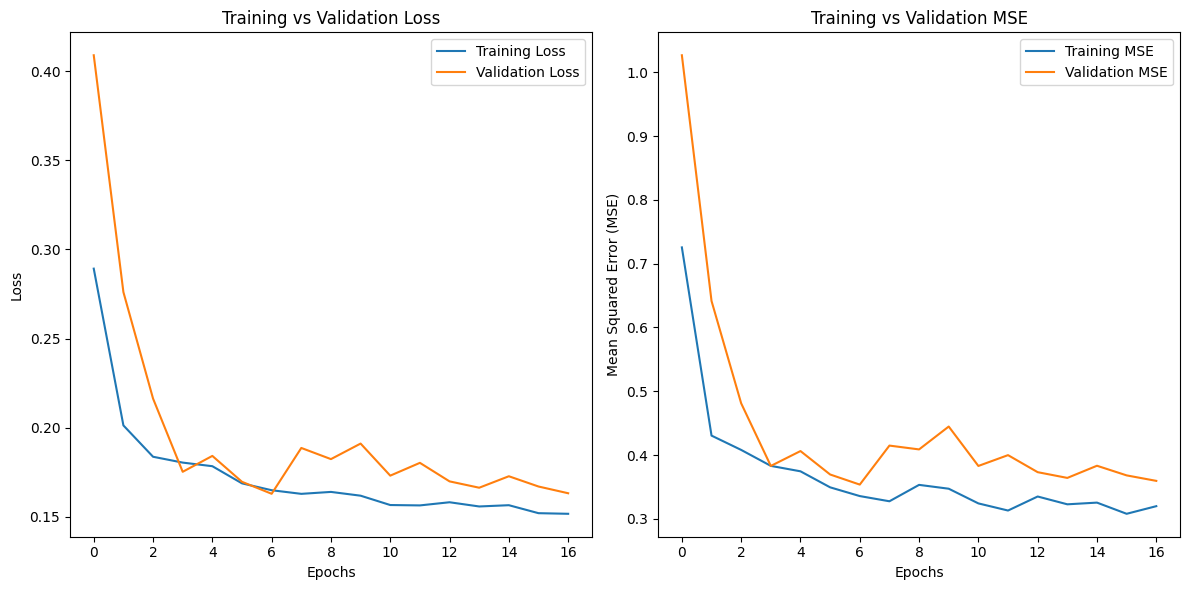

In [109]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.figure(figsize=(12, 6))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot mean squared error (if available)
plt.subplot(1, 2, 2)
plt.plot(history.history['mse'], label='Training MSE')
plt.plot(history.history['val_mse'], label='Validation MSE')
plt.title('Training vs Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()

plt.tight_layout()
plt.show()


In [110]:
cfr_pred_val = simple_cfr_model.predict(X_val_cfr).flatten()
cfr_rmse = np.sqrt(mean_squared_error(y_val_cfr, cfr_pred_val))
print("\nModel Evaluation Results:")
print(f"CFR Prediction RMSE: {cfr_rmse:.2f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Model Evaluation Results:
CFR Prediction RMSE: 0.59


#### Advanced - With Residual Block

In [111]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Input,
    Concatenate, LeakyReLU, Add, LayerNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1_l2
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler
import numpy as np
import math
import matplotlib.pyplot as plt

# Build the enhanced Neural Network model
input_dim = X_train_scaled.shape[1]
inputs = Input(shape=(input_dim,))

# Deep branch
x1 = Dense(256, kernel_regularizer=l1_l2(1e-5, 1e-4))(inputs)
x1 = BatchNormalization()(x1)
x1 = LeakyReLU(alpha=0.1)(x1)
x1 = Dropout(0.3)(x1)

# Residual block 1
skip1 = x1
x1 = Dense(128, kernel_regularizer=l1_l2(1e-5, 1e-4))(x1)
x1 = LayerNormalization()(x1)
x1 = LeakyReLU(alpha=0.1)(x1)
x1 = Dropout(0.3)(x1)
x1 = Dense(128, kernel_regularizer=l1_l2(1e-5, 1e-4))(x1)
x1 = LayerNormalization()(x1)
skip1 = Dense(128)(skip1)
x1 = Add()([x1, skip1])
x1 = LeakyReLU(alpha=0.1)(x1)

# Residual block 2
skip2 = x1
x1 = Dense(64, kernel_regularizer=l1_l2(1e-5, 1e-4))(x1)
x1 = LayerNormalization()(x1)
x1 = LeakyReLU(alpha=0.1)(x1)
x1 = Dropout(0.2)(x1)
x1 = Dense(64, kernel_regularizer=l1_l2(1e-5, 1e-4))(x1)
x1 = LayerNormalization()(x1)
skip2 = Dense(64)(skip2)
x1 = Add()([x1, skip2])
x1 = LeakyReLU(alpha=0.1)(x1)

# Shallow branch for linear patterns
x2 = Dense(32, kernel_regularizer=l1_l2(1e-5, 1e-4))(inputs)
x2 = LeakyReLU(alpha=0.1)(x2)

# Combine branches
combined = Concatenate()([x1, x2])

# Final layers
x = Dense(32, kernel_regularizer=l1_l2(1e-5, 1e-4))(combined)
x = LeakyReLU(alpha=0.1)(x)
x = Dropout(0.15)(x)

outputs = Dense(1)(x)

cfr_model = Model(inputs=inputs, outputs=outputs)

# Compile with Huber loss for robustness to outliers
optimizer = Adam(learning_rate=0.001)
cfr_model.compile(
    optimizer=optimizer,
    loss='huber',
    metrics=['mse', 'mae']
)

# Prepare callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    )
]

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [112]:
# Train the model
history = cfr_model.fit(
    X_train_cfr,
    y_train_cfr,
    validation_data=(X_val_cfr, y_val_cfr),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 0.3573 - mae: 0.5680 - mse: 0.6517 - val_loss: 0.2962 - val_mae: 0.5080 - val_mse: 0.5016 - learning_rate: 0.0010
Epoch 2/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2508 - mae: 0.4164 - mse: 0.3537 - val_loss: 0.2629 - val_mae: 0.4369 - val_mse: 0.4268 - learning_rate: 0.0010
Epoch 3/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2546 - mae: 0.4235 - mse: 0.3783 - val_loss: 0.2459 - val_mae: 0.4230 - val_mse: 0.3943 - learning_rate: 0.0010
Epoch 4/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2271 - mae: 0.3905 - mse: 0.3119 - val_loss: 0.2383 - val_mae: 0.4374 - val_mse: 0.3612 - learning_rate: 0.0010
Epoch 5/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2170 - mae: 0.3860 - mse: 0.2882 - val_loss: 0.2174 - val_mae: 0.3767 - val_mse: 0.3371 - learning_rate: 0.0010
Epoch 6/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2166 - mae: 0.3894 - mse: 0.3018 - val_loss: 0.2281 - val_mae: 0.3834

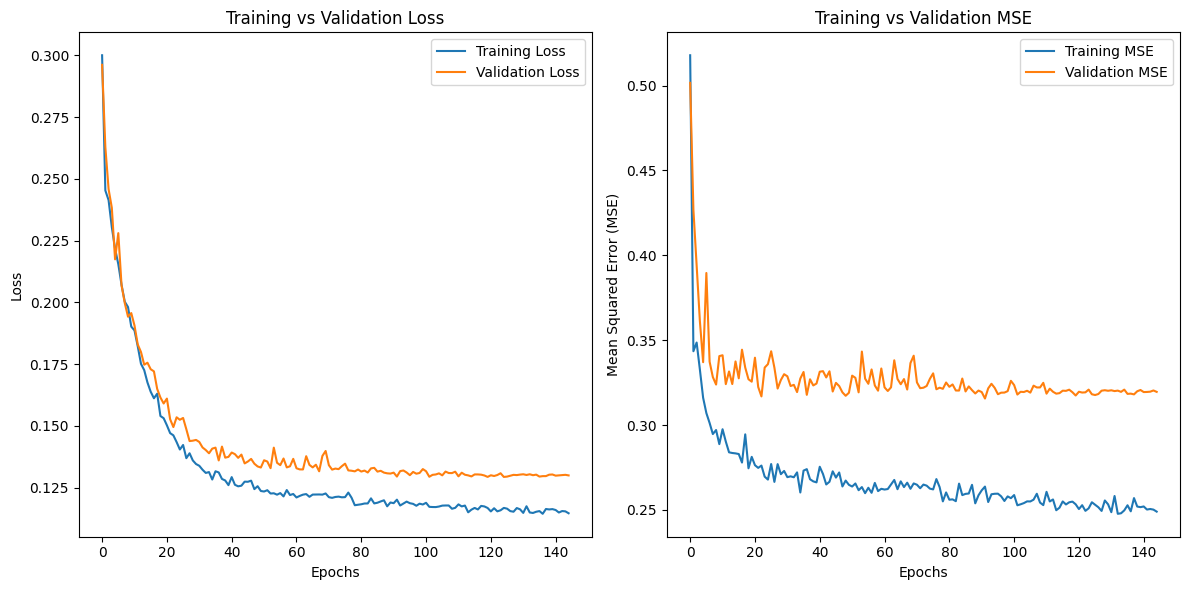

In [113]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.figure(figsize=(12, 6))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot mean squared error (if available)
plt.subplot(1, 2, 2)
plt.plot(history.history['mse'], label='Training MSE')
plt.plot(history.history['val_mse'], label='Validation MSE')
plt.title('Training vs Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()

plt.tight_layout()
plt.show()


In [114]:
cfr_pred_val = cfr_model.predict(X_val_cfr).flatten()
cfr_rmse = np.sqrt(mean_squared_error(y_val_cfr, cfr_pred_val))
print("\nModel Evaluation Results:")
print(f"CFR Prediction RMSE: {cfr_rmse:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

Model Evaluation Results:
CFR Prediction RMSE: 0.5641


# Predictions

From the lot of experiments and testing below contain the best features and best model for both death and cfr prediction and we use them to make the final predictions



### Death Best Model with IDW

In [115]:
# Define feature columns
feature_columns = [
        'Lat', 'Long_',
         '2022 Avg Temp',
        'cluster_mean_deaths',
    ]

# Scale features
scaler = StandardScaler()
X_train = train_df[feature_columns]
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_columns
)

X_test = test_df[feature_columns]
X_test_scaled_deaths = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_columns
)
# Train models
print("\nTraining models...")
target_columns= 'Deaths'
# Death prediction
death_mask = train_df[target_columns].notna()
X_death = X_train_scaled[death_mask]
y_death = train_df.loc[death_mask, target_columns]
# Split data
X_train_death, X_val_death, y_train_death, y_val_death = train_test_split(
    X_death, y_death, test_size=0.1, random_state=42
)


# Train death model
death_model = BaggingRegressor(estimator=xgb.XGBRegressor(n_estimators=50), n_estimators=50, random_state=42)
death_model.fit(X_train_death, y_train_death)
death_pred_val = death_model.predict(X_val_death)
death_rmse = np.sqrt(mean_squared_error(y_val_death, death_pred_val))
print(f"Death Prediction RMSE: {death_rmse:.4f}")


Training models...
Death Prediction RMSE: 31.1484


### CFR Best Model with IDW

In [116]:
# Define feature columns
feature_columns = [

        'cluster_mean_CFR',
        'spatial_lag_CFR',
        'spatial_density',

    ]

    # Scale features
scaler = StandardScaler()
X_train = train_df[feature_columns]
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_columns
)

X_test = test_df[feature_columns]
X_test_scaled_cfr = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_columns
)

target_col = 'Case_Fatality_Ratio'
# CFR prediction
cfr_mask = train_df[target_col].notna()
X_cfr = X_train_scaled[cfr_mask]
y_cfr = train_df.loc[cfr_mask, target_col]

X_train_cfr, X_val_cfr, y_train_cfr, y_val_cfr = train_test_split(
    X_cfr, y_cfr, test_size=0.1, random_state=42
)

# Train death model
cfr_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
cfr_model.fit(X_train_cfr, y_train_cfr)
cfr_pred_val = cfr_model.predict(X_val_cfr)
cfr_rmse = np.sqrt(mean_squared_error(y_val_cfr, cfr_pred_val))
print(f"Death Prediction RMSE: {cfr_rmse:.4f}")

Death Prediction RMSE: 0.4906


### Final Predictions

In [117]:
# Generate predictions
print("\nGenerating predictions...")
predicted_deaths = death_model.predict(X_test_scaled_deaths)
predicted_cfr = cfr_model.predict(X_test_scaled_cfr).flatten()



# Clean up predictions
predicted_deaths = np.maximum(predicted_deaths, 0)
predicted_cfr = np.clip(predicted_cfr, 0.1, 100.0)
predicted_confirmed = (predicted_deaths / predicted_cfr) * 100

# Create submission dataframe
submission_df = pd.DataFrame({
    'Lat': test_df['Lat'],
    'Long_': test_df['Long_'],
    'Predicted_Deaths': predicted_deaths,
    'Predicted_CFR': predicted_cfr,
    'Predicted_Confirmed_Cases': predicted_confirmed
})

# Save predictions
submission_df.to_csv('Final_submission_90.csv', index=False)
print("\nSubmission file created successfully!")


Generating predictions...

Submission file created successfully!
